# Fit a 2D exponential

### Charlotte Christensen, Dimitra Giantsidi & Nolan Ottele 2026

#### Fits a 2D exponential to a 2D histogram of star counts from matched-filter outputs. Achieves the isolation of streams (and objects in general) from the rest of the galaxy. It masks out the center to avoid central anomalies.

In [1]:
# import all necessary libaries
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pathlib import Path as path
import os
import re

In [2]:
# define the galaxy of choice and its depth, distance and resolution
box = 'rogue'
num = '5'
galaxy_name = f'{box}_{num}'
depth = 26
distance = 2000
numpix = 8000

In [3]:
# define the necessarily already-existing file paths
mf_catalogs_path = path(f'../matched_filter/mf_data/mf_catalogs/{depth}_{distance}/{galaxy_name}')
centers_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/centers.txt')
centers_path.parent.mkdir(parents=True, exist_ok=True)
best_init_guess_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/best_init_guess.txt')
best_init_guess_path.parent.mkdir(parents=True, exist_ok=True)

In [4]:
def exponential_2d(coords, A, h, q, x_offset, y_offset, theta, C):
    """ The 2D exponential model function.

    Params:
        coords (2D array of floats):
            The 2D array of data in the XY plane.
        A (float):
            Amplitude.
        h (float):
            Scale length.
        q (float):
            Axis ratio (minor/major; related to orientation).
        x_offset (float):
            distance of the center of the galaxy from the center of the image on the x-axis.
        y_offset (float):
            distance of the center of the galaxy from the center of the image on the y-axis.
        theta (float):
            Rotation angle in viewing plane (0 means major axis is along the x-axis, pi/2 means major axis is along the y-axis).
        C (float):
            Offset from background (should be about 0).

    Returns:
        exp_fit (array of floats):
            The calculated 2D exponential fit values.
    """
    x = coords[0] - x_offset
    y = coords[1] - y_offset
    x_prime = x * np.cos(theta) + y * np.sin(theta)
    y_prime = -x * np.sin(theta) + y * np.cos(theta)
    r = np.sqrt(x_prime**2 + y_prime**2/q**2)
    exp_fit = A * np.exp(-r/h) + C
    return exp_fit

In [5]:
def plot(plot_data, save_folder, d, a, save=True, save_fits=False, inv_y=False):
    """ Plots the data passed and optionally saves the resulting image as a .png.

    Args:
        plot_data (2D array of floats):
            The desired data in a 2D array with assigned values.
        save_folder (string):
            The desired save folder for the type of data received (the original data, the model exponential fit or the residuals)
        d (float):
            Declination.
        a (float):
            Azimuth.
        save (boolean):
            The boolean defining whether to save the image or not. Defaults to true.
        inv_y (boolean):
            The boolean defining whether to invert the y-axis of the image. Defaults to false.

    Returns:
        None
    """

    # create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # plot the original noisy data as an image
    im = ax.imshow(plot_data, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
                   cmap='gray', vmin=0, vmax=30, aspect='auto')

    # overlay contours of the fitted result
    levels_arr = 10.0**np.array([-4,-3,-2,-1])*(A_fit + C_fit)
    #contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=levels_arr, alpha=0.8)
    #ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

    # add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Stellar Density Level', rotation=270, labelpad=20)

    # labels and title
    ax.set_xlabel('X\' (kpc)')
    ax.set_ylabel('Y\' (kpc)')
    #ax.set_title(f'{galaxy_name}: 2D exponential fit: {save_folder}')

    plt.tight_layout()

    if inv_y==True:
        plt.gca().invert_yaxis()

    if save==True:
        save_path = path(f'sd_outputs/twod_exp_fit/{galaxy_name}/{save_folder}/{galaxy_name}_{save_folder}_d={d}_a={a}_pix={numpix}.png')
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path)

    if save_fits==True:
        fits_save_path=path(f'sd_outputs/twod_exp_fit/{galaxy_name}/fits_files/{galaxy_name}_d={d}_a={a}_pix={numpix}.fits')
        fits_save_path.parent.mkdir(parents=True, exist_ok=True)
        hdu = fits.PrimaryHDU(plot_data)
        hdu.writeto(fits_save_path, overwrite=True)
    
    plt.show()

In [12]:
# provide a sensible initial guess (p0) to prevent divergence
# form: [A, h, q, x_offset, y_offset, theta, C]
initial_guess = [2700, 1.15, 0.95, 1.45, 0.28, 0, -0.13]
mask_cutoff = 0.05

# when applying the algorithm to a new galaxy, use this to save the best initial guess for future reference
update = False
if update == True:
    if os.path.exists(best_init_guess_path):
        os.remove(best_init_guess_path)
    with open(f'{best_init_guess_path}', 'a') as file:
                file.write('Best initial guess for ' f'{galaxy_name}' ': ' \
                           f'{initial_guess[0]}' ', ' \
                           f'{initial_guess[1]}' ', ' \
                           f'{initial_guess[2]}' ', ' \
                           f'{initial_guess[3]}' ', ' \
                           f'{initial_guess[4]}' ', ' \
                           f'{initial_guess[5]}' ', ' \
                           f'{initial_guess[6]}' '.' \
                          '\nMask cut-off at: ' f'{mask_cutoff}')

File name: mf_rogue_5_d=0.0_a=0.0_pix=8000.fits
Fitted Parameters:
A  = 2785.6871
h = 1.0397
q = 1.1562
x_offset = 1.6770
y_offset = 0.3747
theta = 0.0367
C  = -0.1164


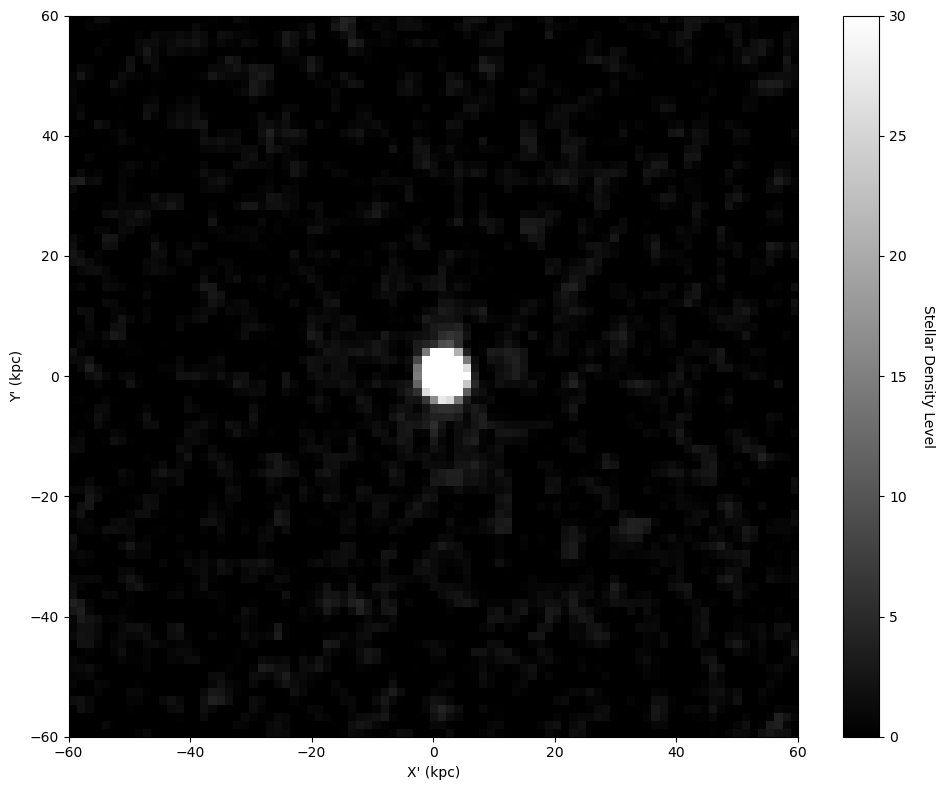

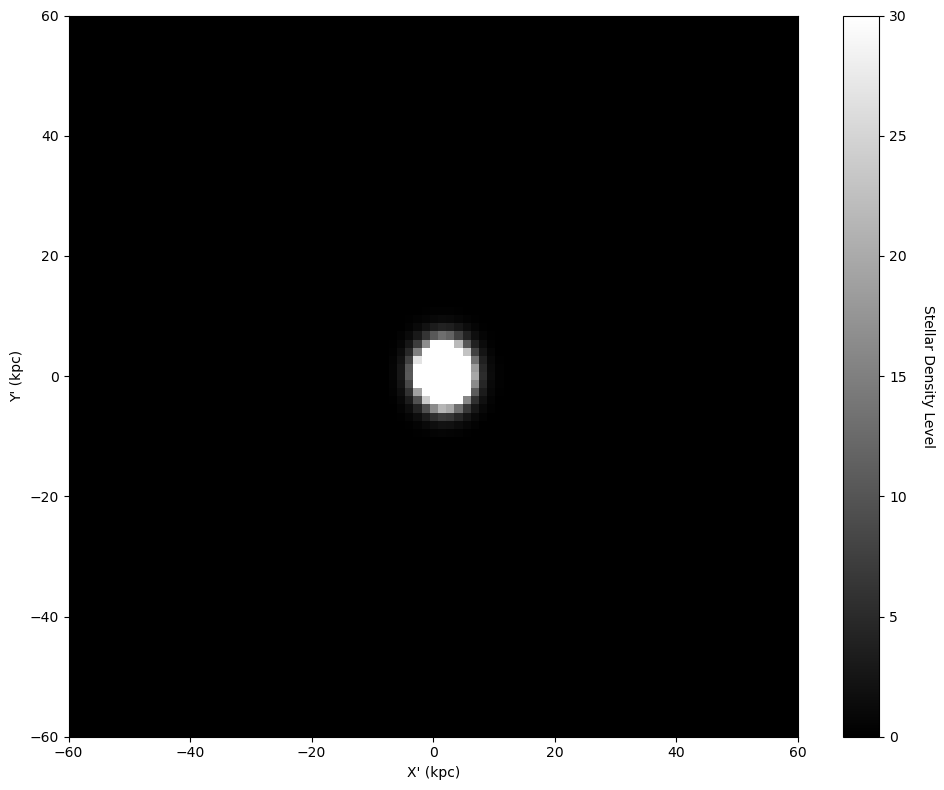

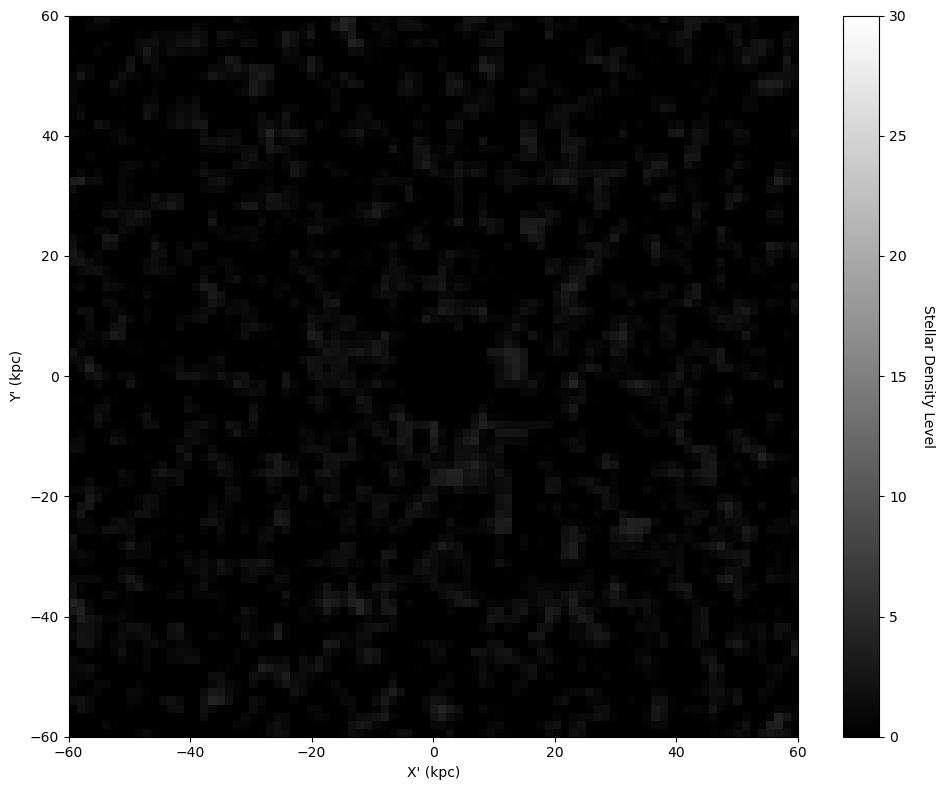

File name: mf_rogue_5_d=17.0_a=222.5_pix=8000.fits
Fitted Parameters:
A  = 2622.3913
h = 1.2540
q = 0.8577
x_offset = 1.4234
y_offset = 0.3136
theta = 0.3815
C  = -0.1568


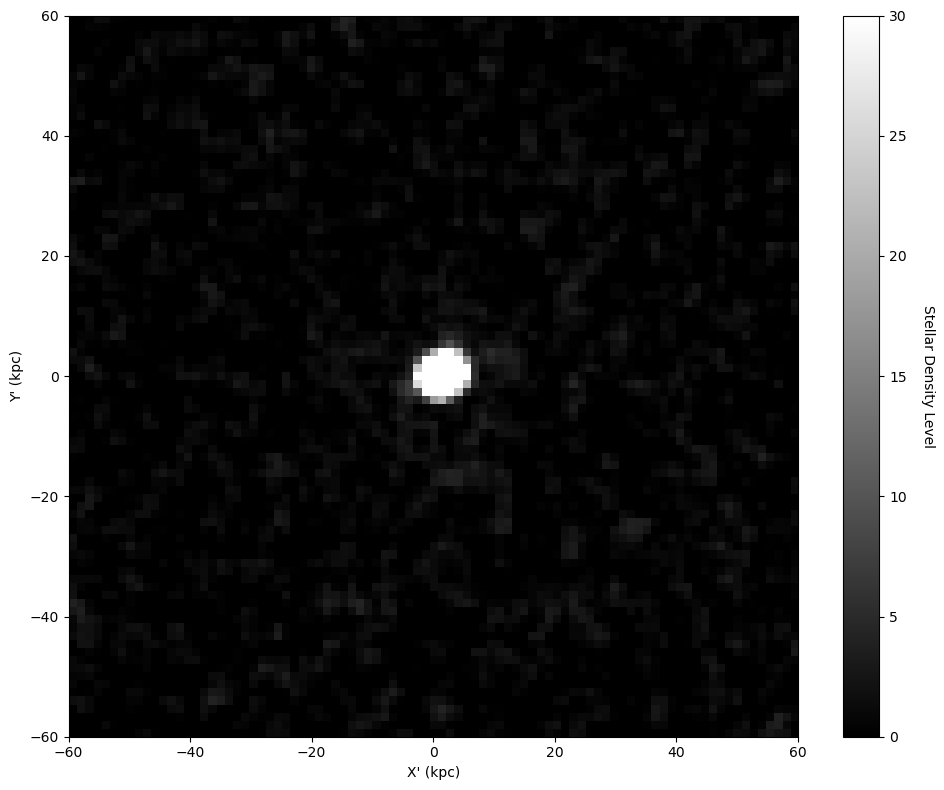

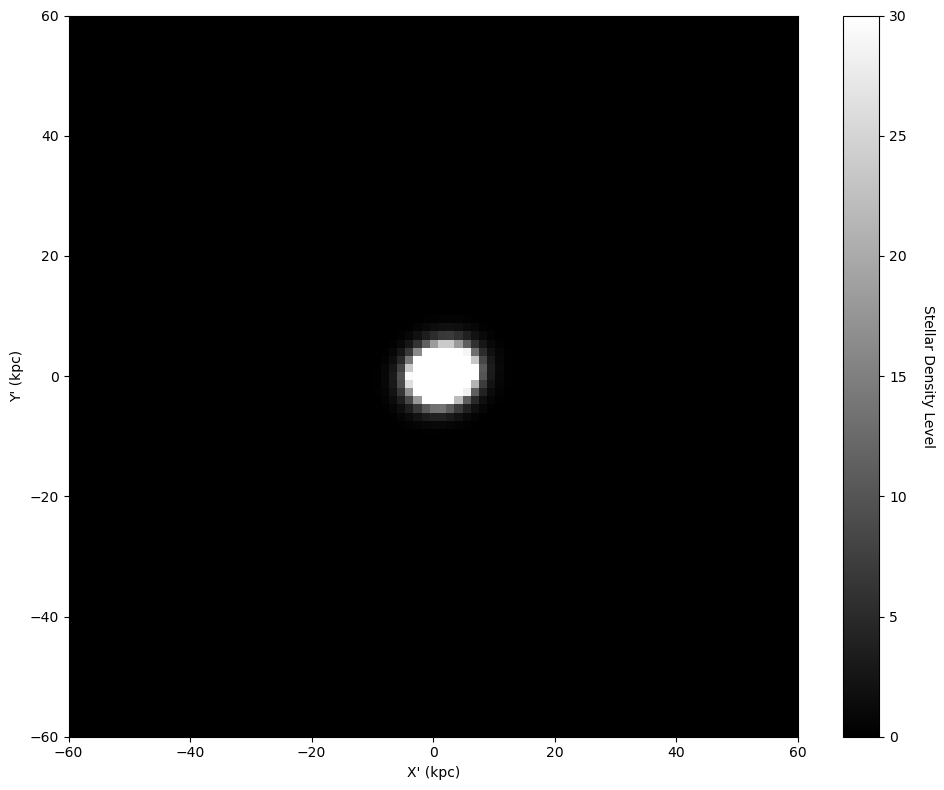

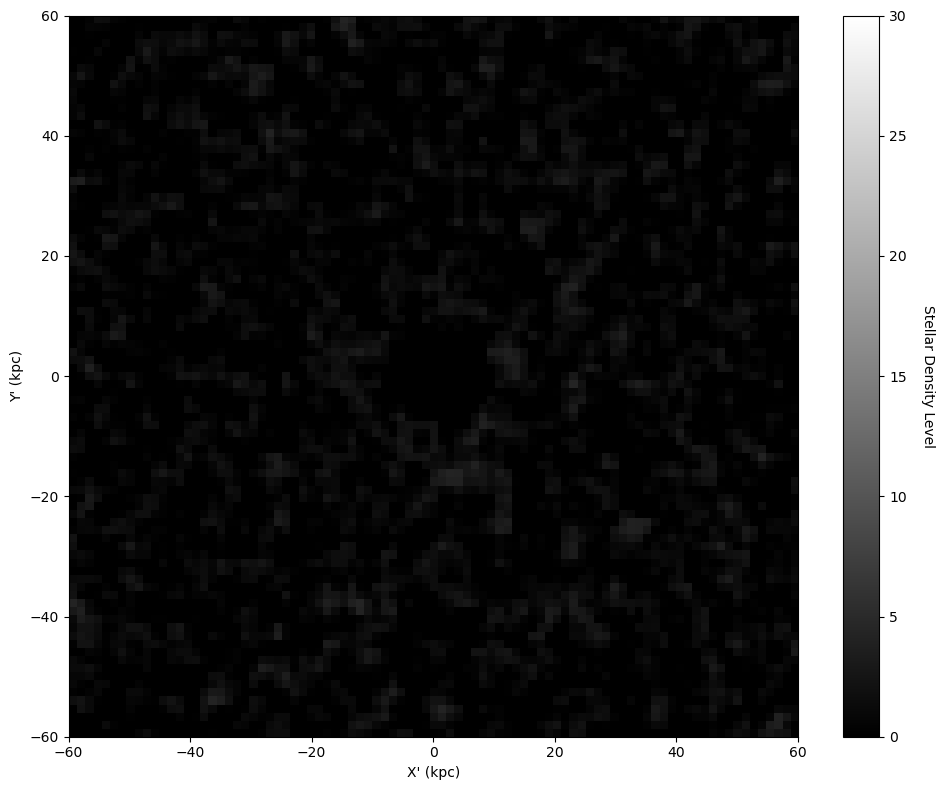

File name: mf_rogue_5_d=24.1_a=85.0_pix=8000.fits
Fitted Parameters:
A  = 2706.7802
h = 1.2246
q = 0.8666
x_offset = 1.7098
y_offset = 0.1402
theta = -0.5195
C  = -0.1358


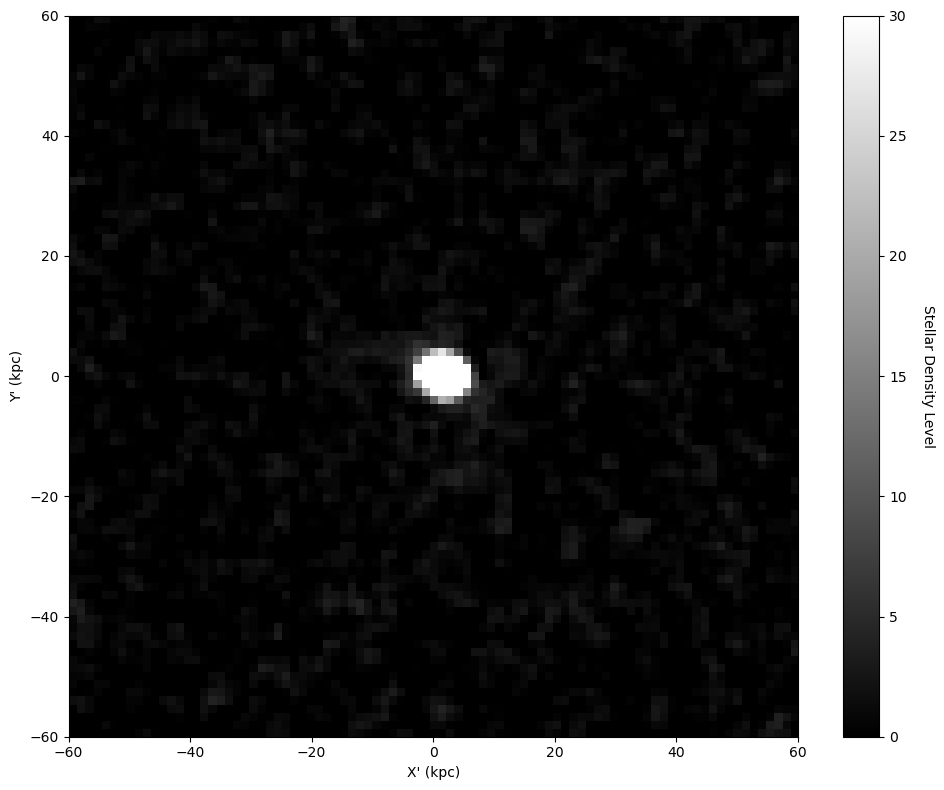

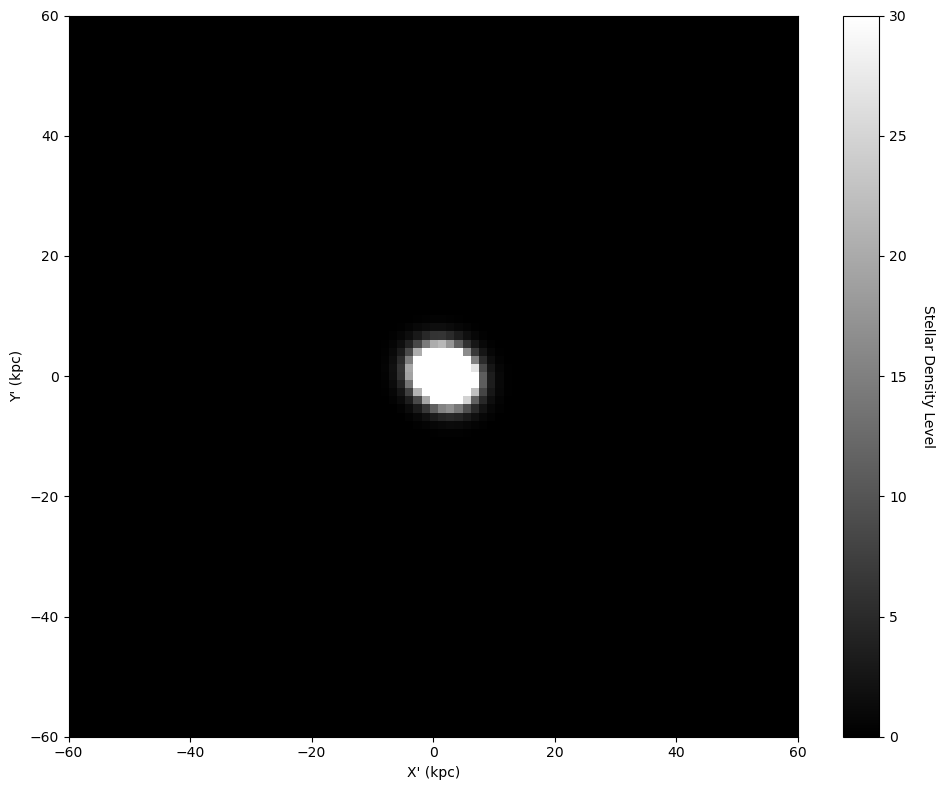

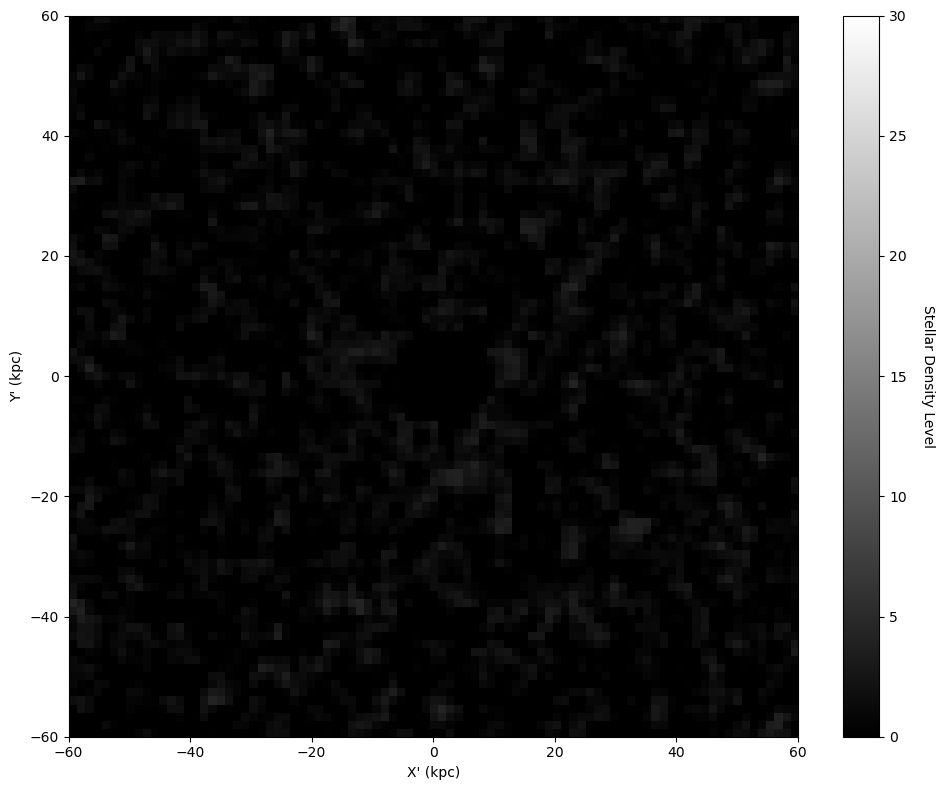

File name: mf_rogue_5_d=29.6_a=307.5_pix=8000.fits
Fitted Parameters:
A  = 2946.8636
h = 1.1641
q = 0.8767
x_offset = 1.4708
y_offset = 0.4275
theta = -3.6725
C  = -0.1181


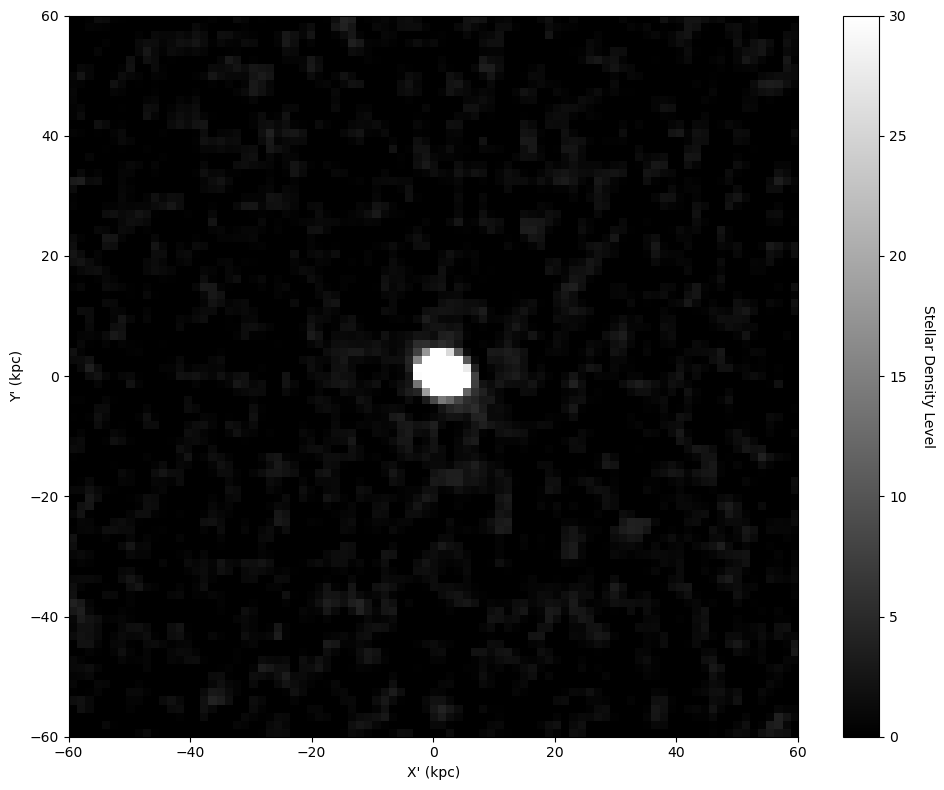

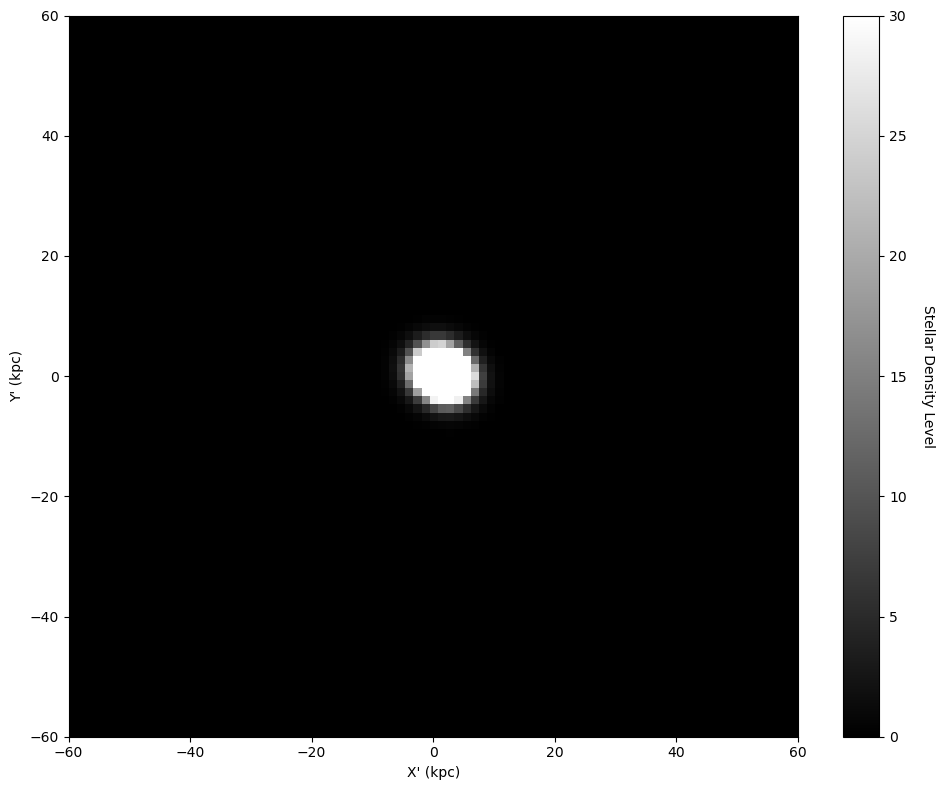

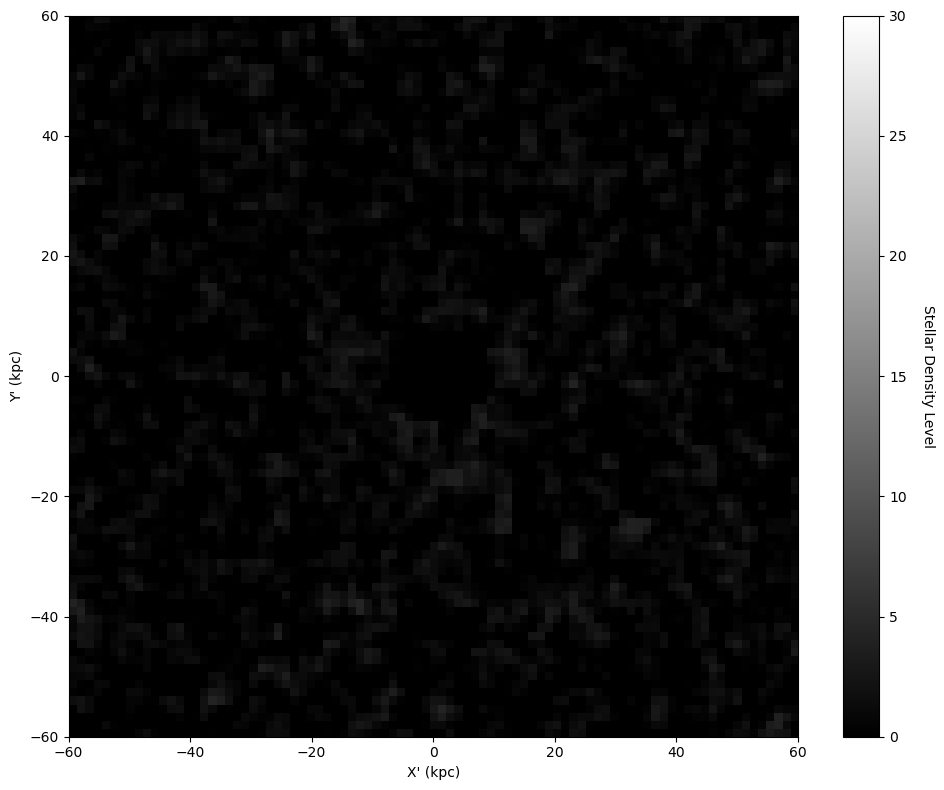

File name: mf_rogue_5_d=34.3_a=170.0_pix=8000.fits
Fitted Parameters:
A  = 2679.8383
h = 1.1004
q = 1.0948
x_offset = 1.5273
y_offset = 0.2476
theta = 0.0409
C  = -0.1617


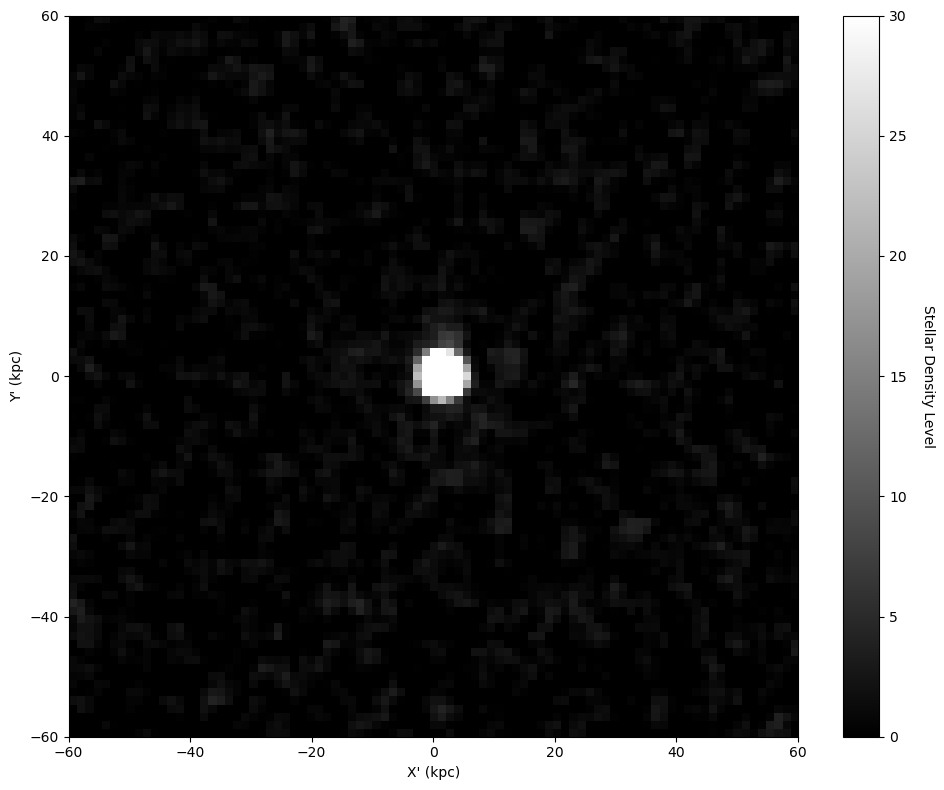

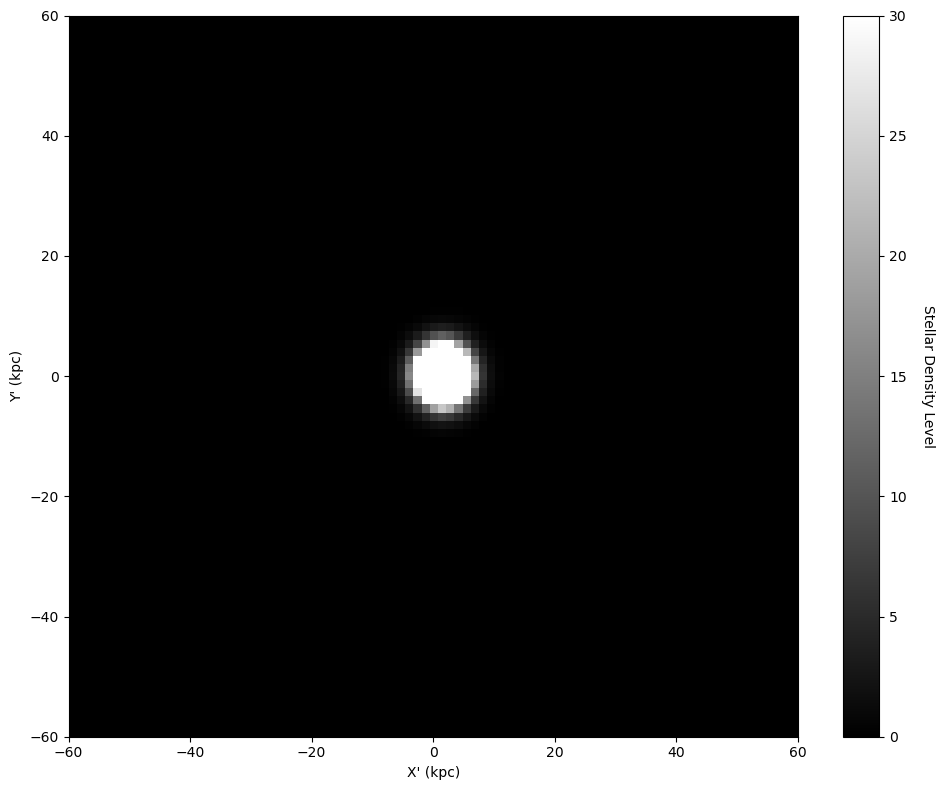

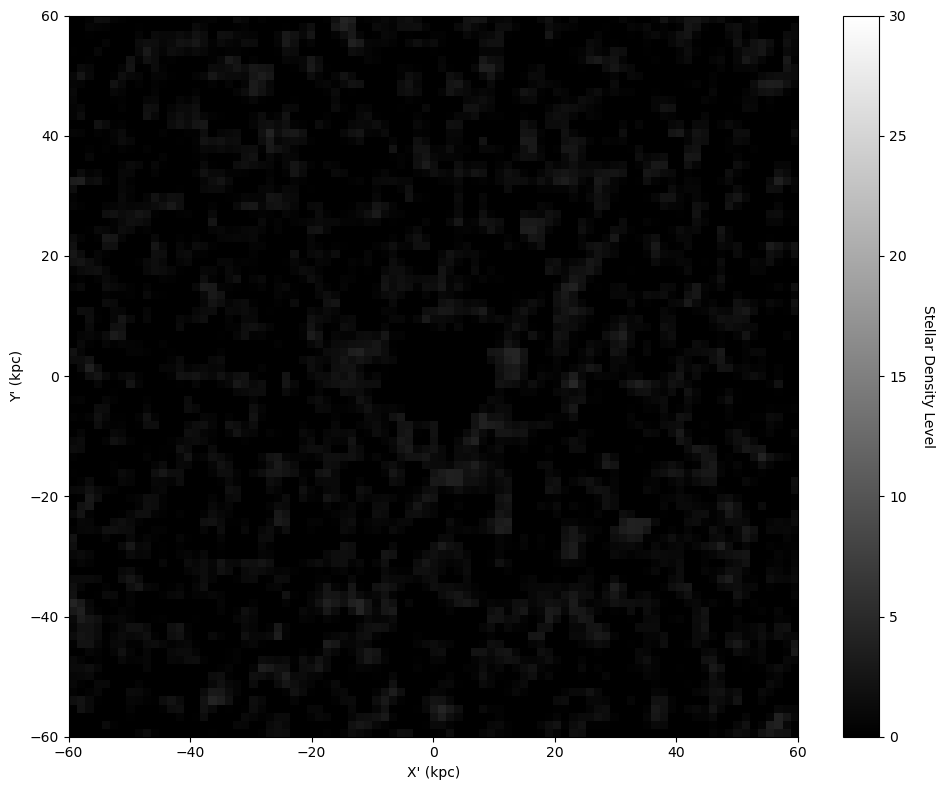

File name: mf_rogue_5_d=38.5_a=32.5_pix=8000.fits
Fitted Parameters:
A  = 2956.1197
h = 1.1558
q = 0.8993
x_offset = 1.7333
y_offset = 0.2724
theta = 0.3045
C  = -0.1341


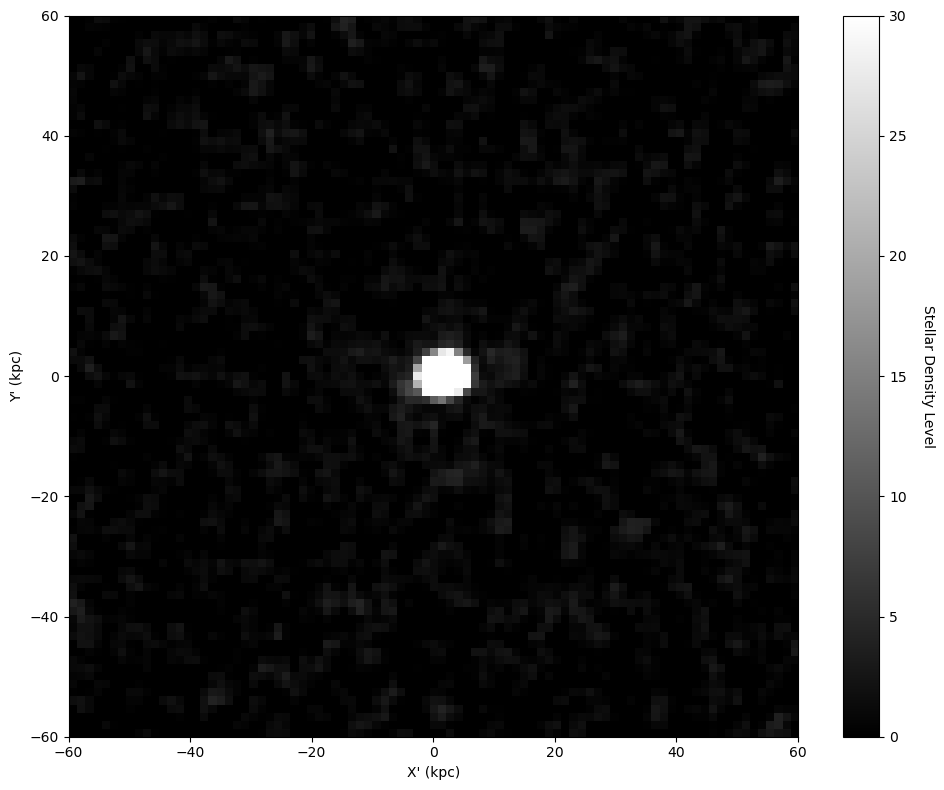

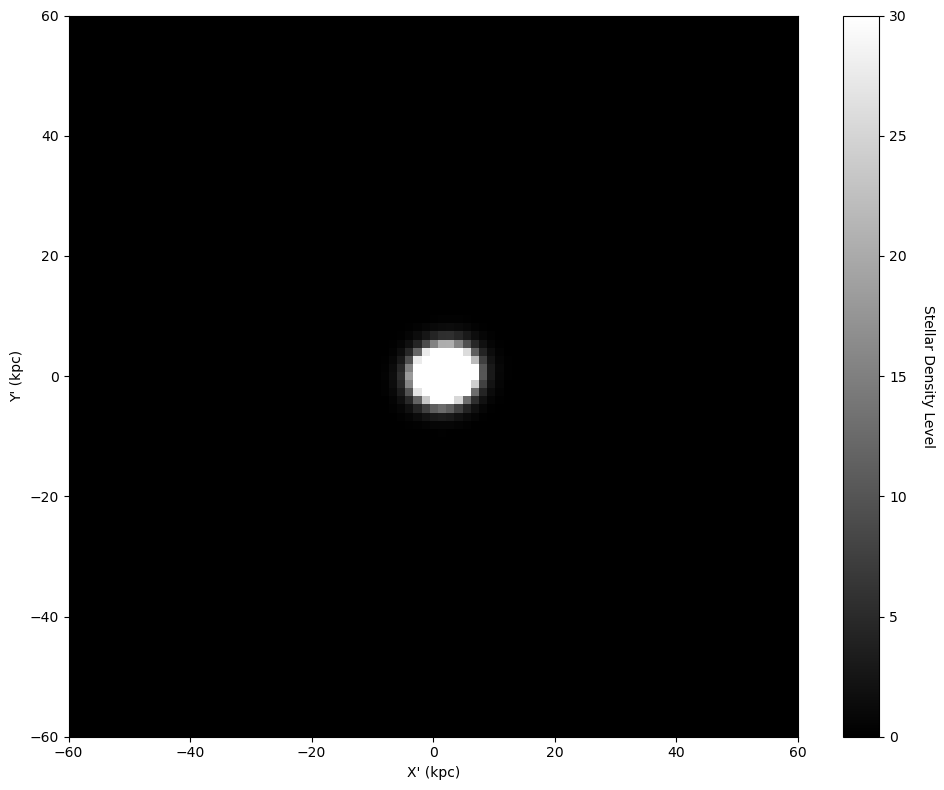

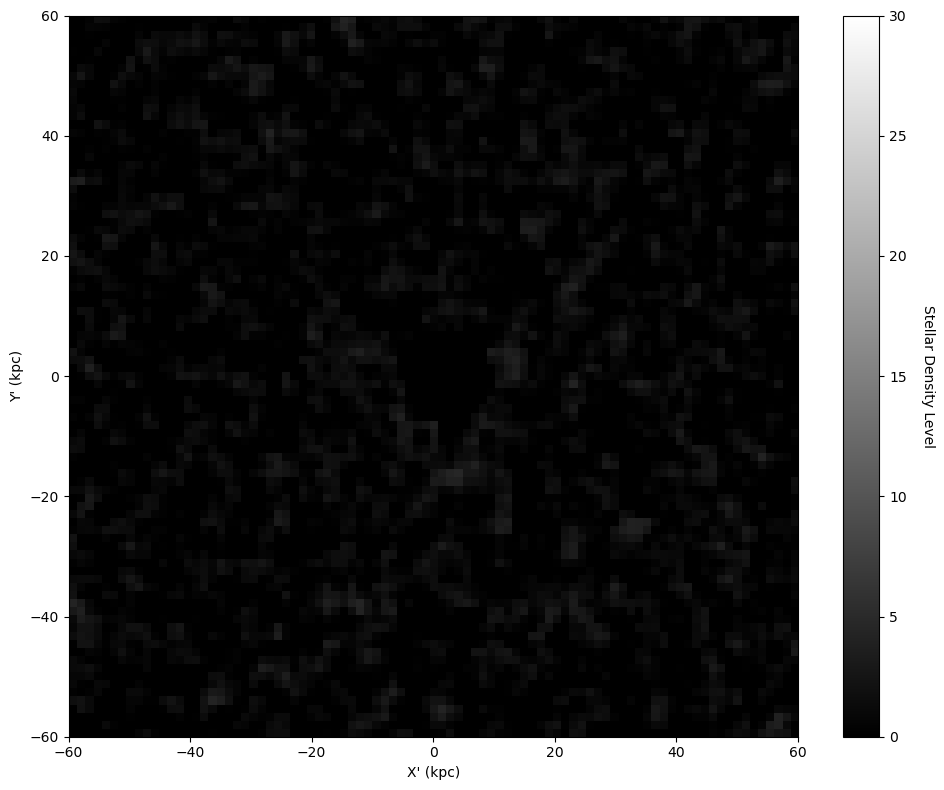

File name: mf_rogue_5_d=42.3_a=255.0_pix=8000.fits
Fitted Parameters:
A  = 2863.4498
h = 1.2641
q = 0.7655
x_offset = 1.3152
y_offset = 0.3549
theta = 0.0201
C  = -0.1318


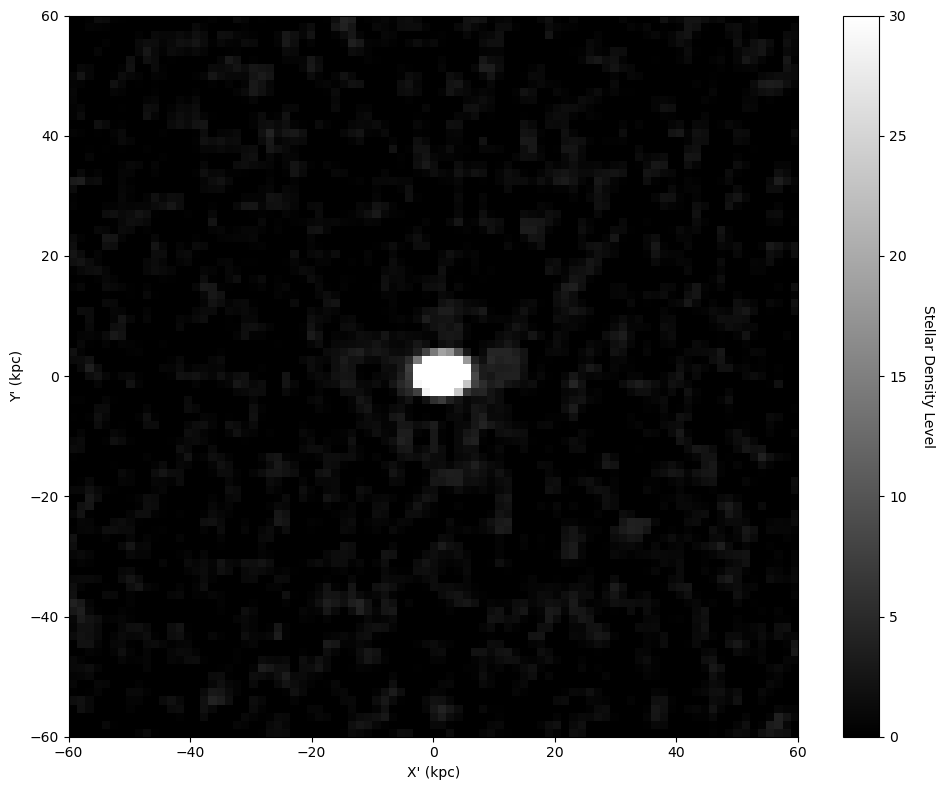

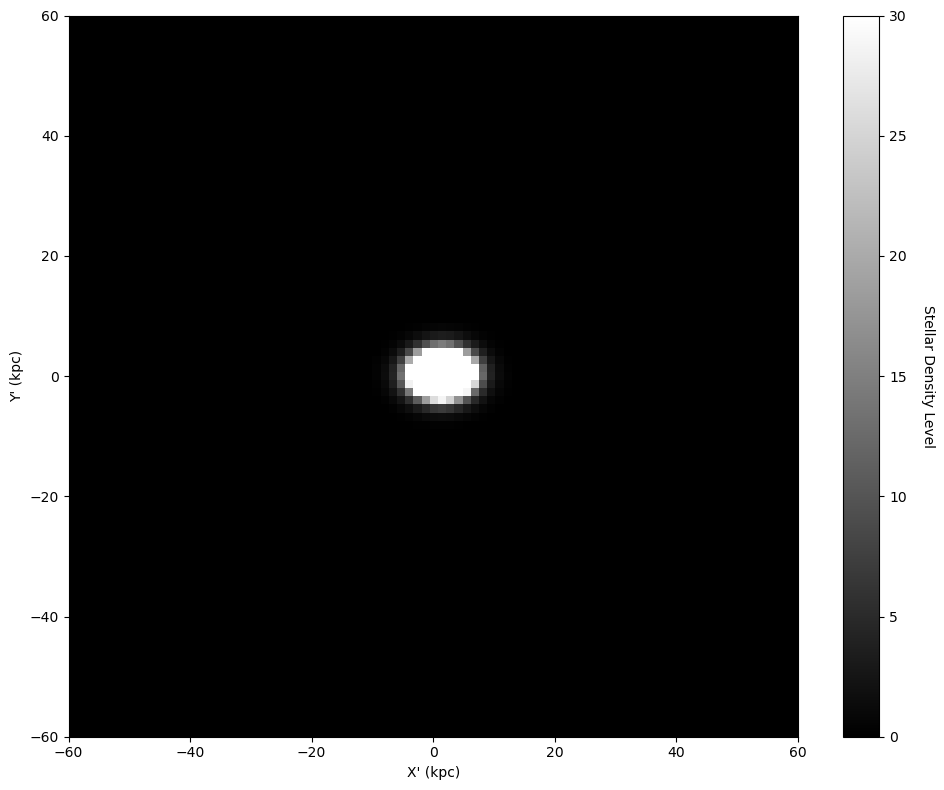

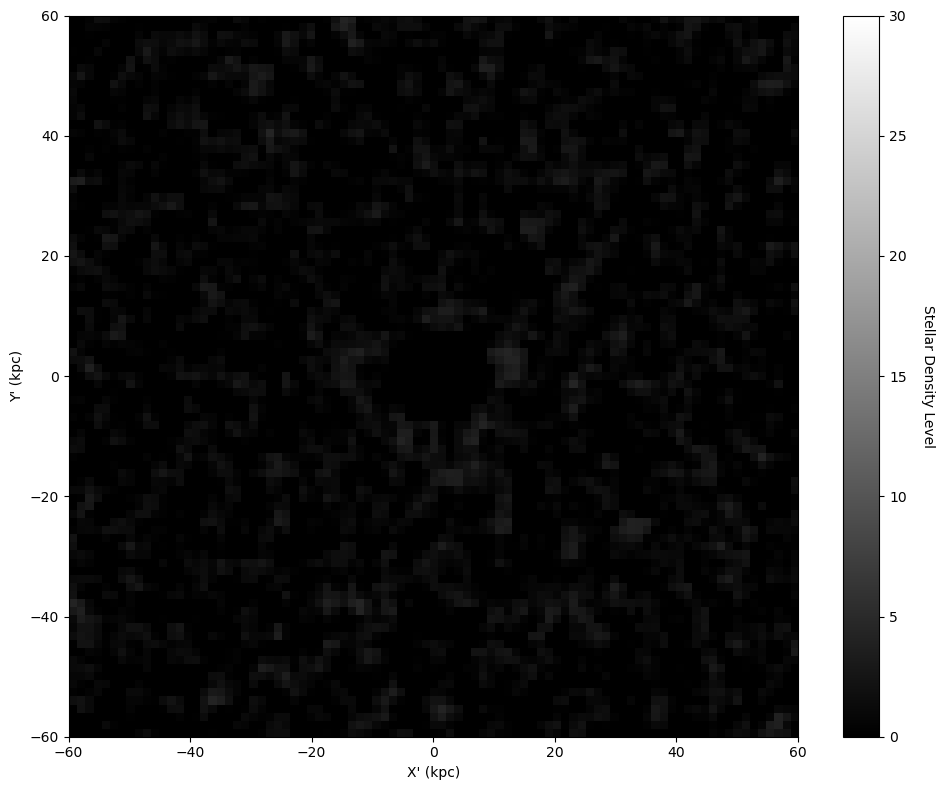

File name: mf_rogue_5_d=45.9_a=117.4_pix=8000.fits
Fitted Parameters:
A  = 2763.2754
h = 1.2138
q = 0.8708
x_offset = 1.5368
y_offset = 0.2407
theta = -0.6503
C  = -0.1614


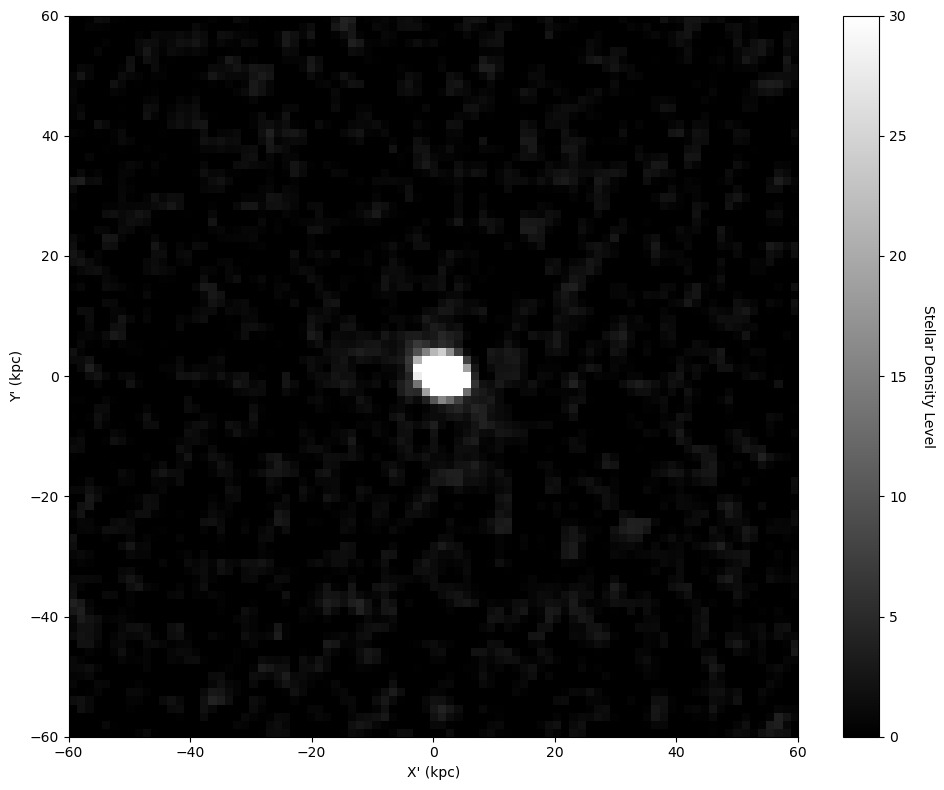

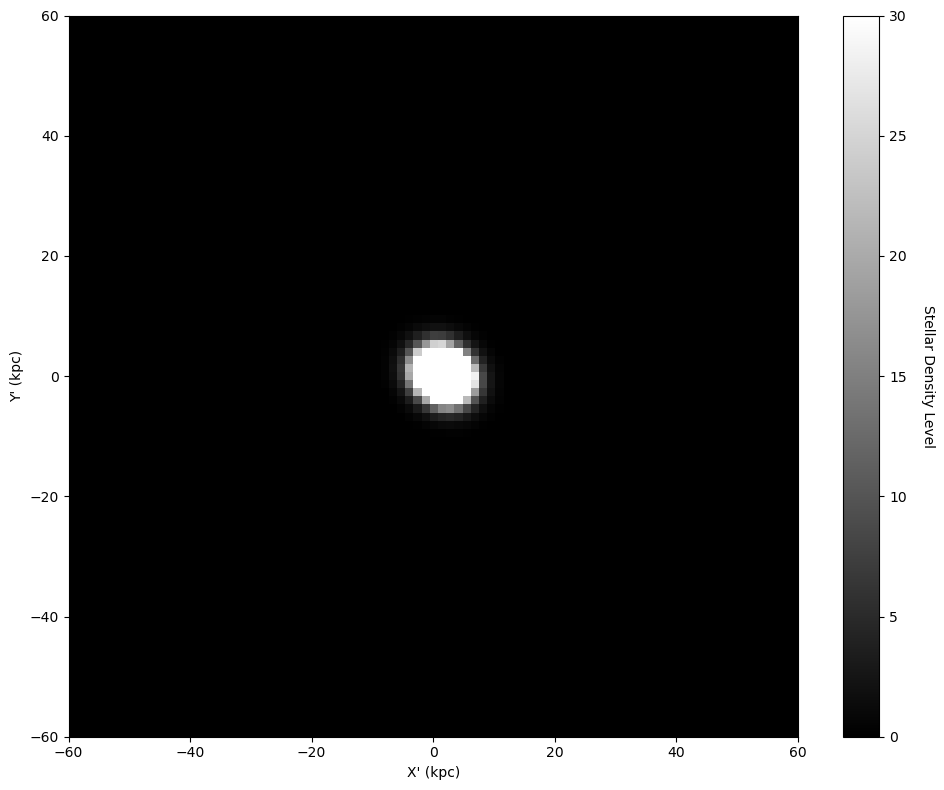

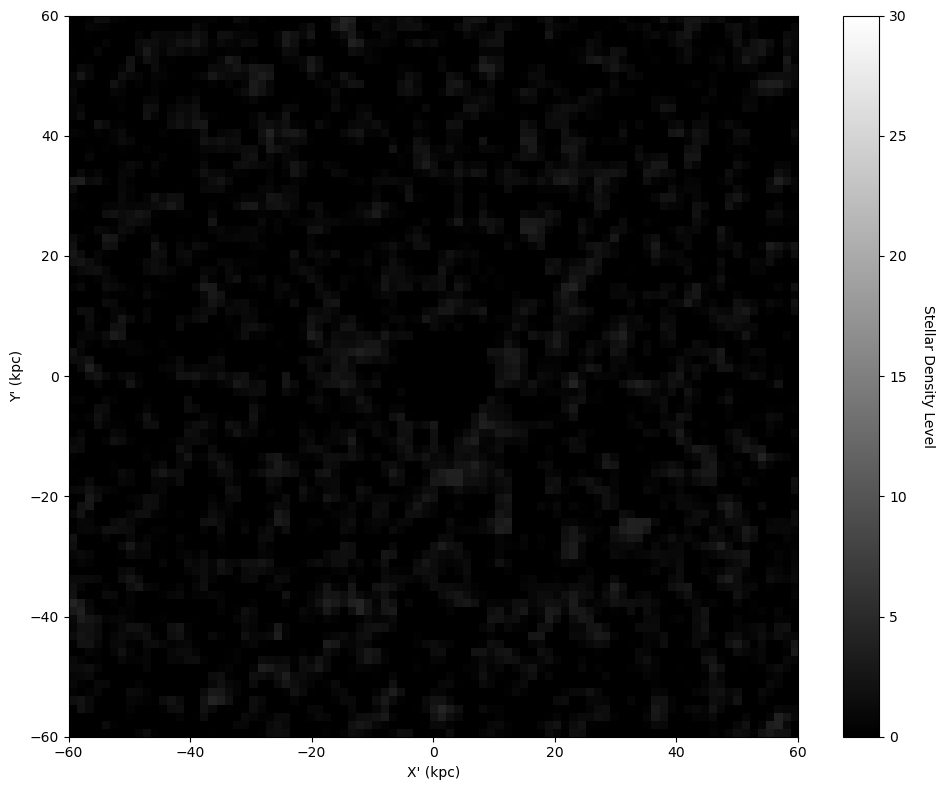

File name: mf_rogue_5_d=49.3_a=339.9_pix=8000.fits
Fitted Parameters:
A  = 3161.5863
h = 1.0974
q = 0.9271
x_offset = 1.4065
y_offset = 0.4120
theta = -0.1515
C  = -0.1352


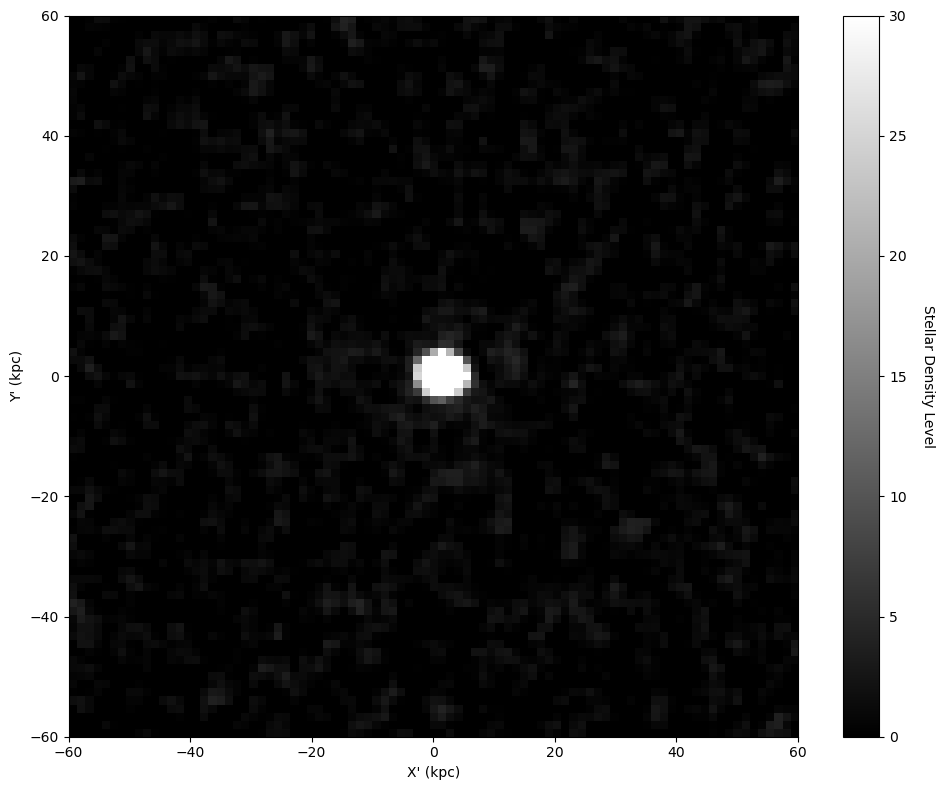

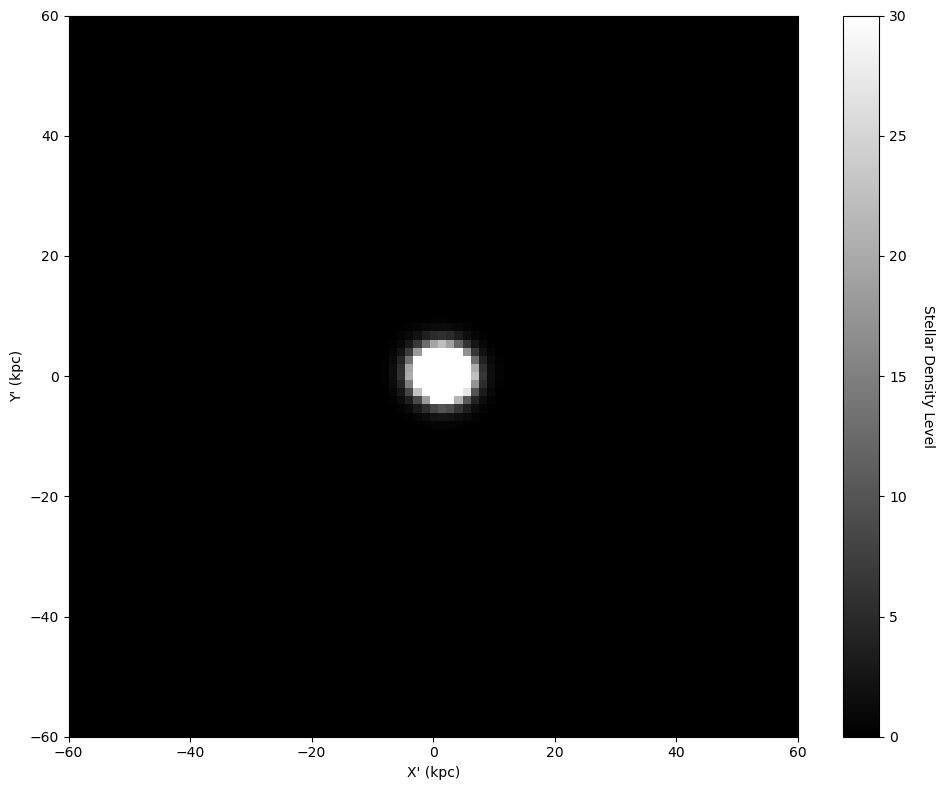

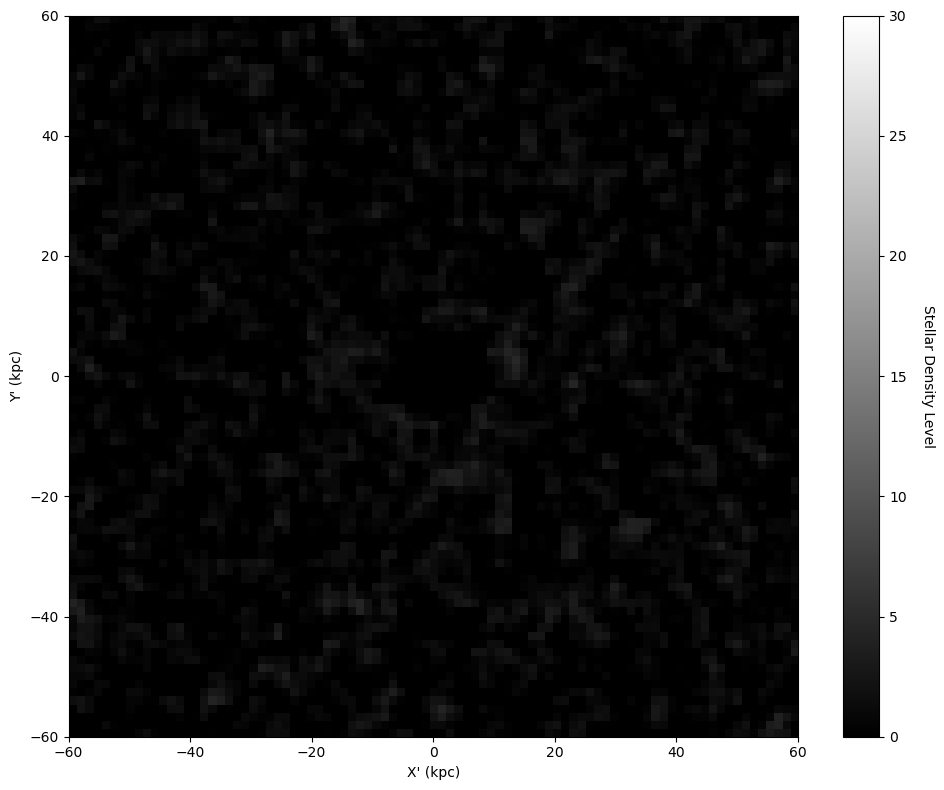

File name: mf_rogue_5_d=52.5_a=202.4_pix=8000.fits
Fitted Parameters:
A  = 2903.1960
h = 1.1928
q = 0.8596
x_offset = 1.2152
y_offset = 0.2696
theta = -2.5217
C  = -0.1634


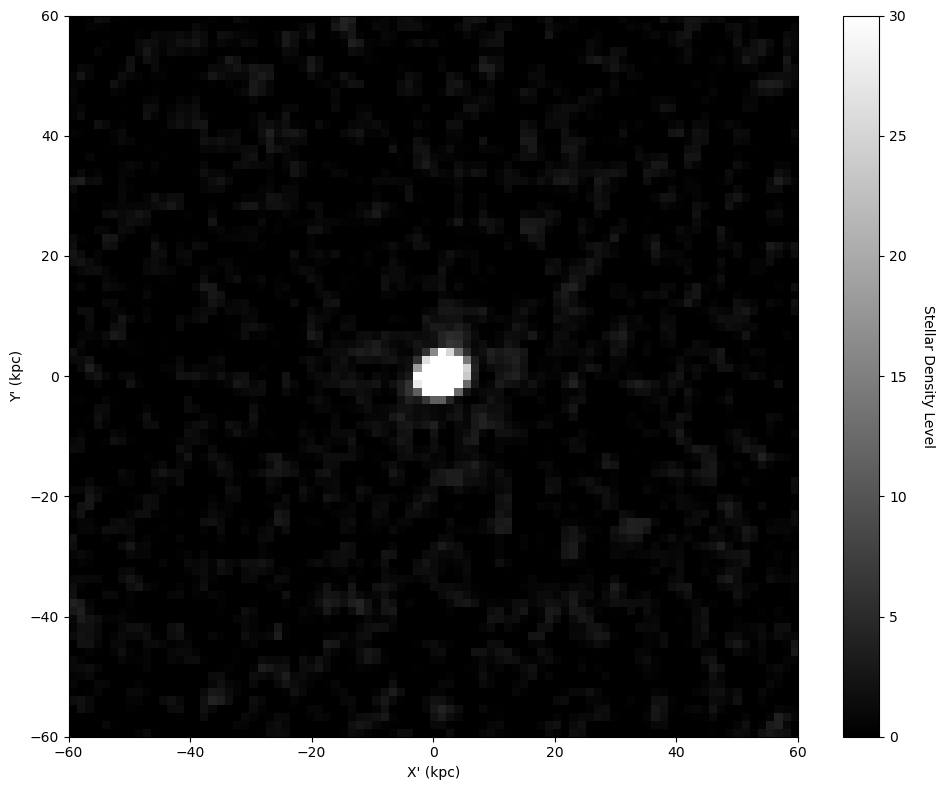

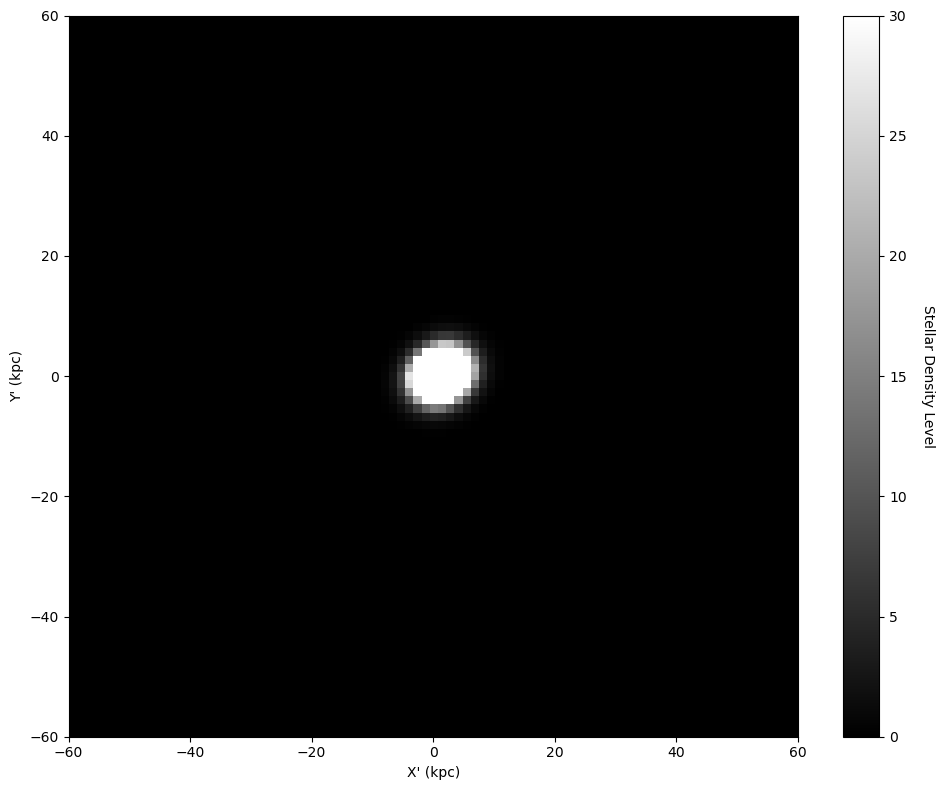

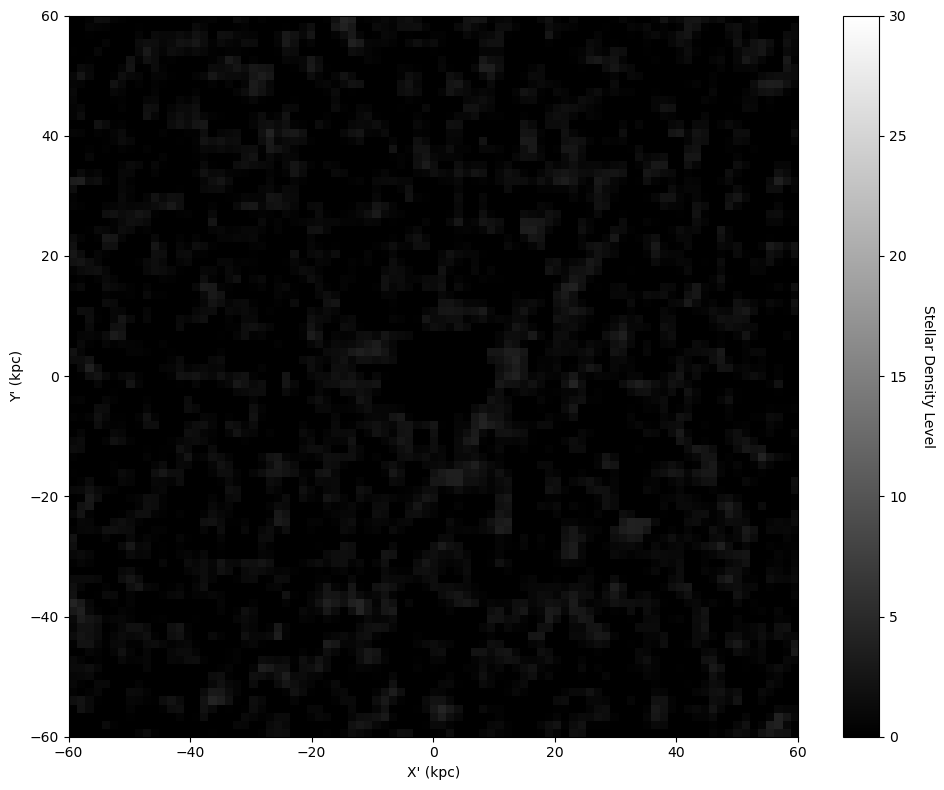

File name: mf_rogue_5_d=55.6_a=64.9_pix=8000.fits
Fitted Parameters:
A  = 2927.3420
h = 1.2617
q = 0.7626
x_offset = 1.6546
y_offset = 0.2423
theta = -0.1359
C  = -0.1418


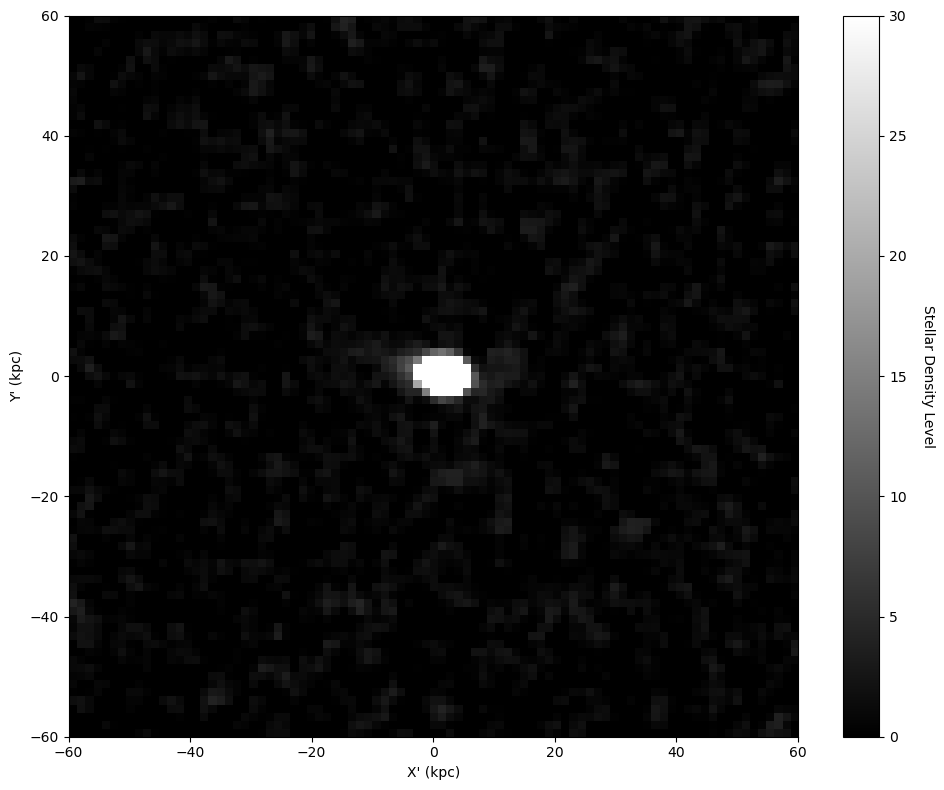

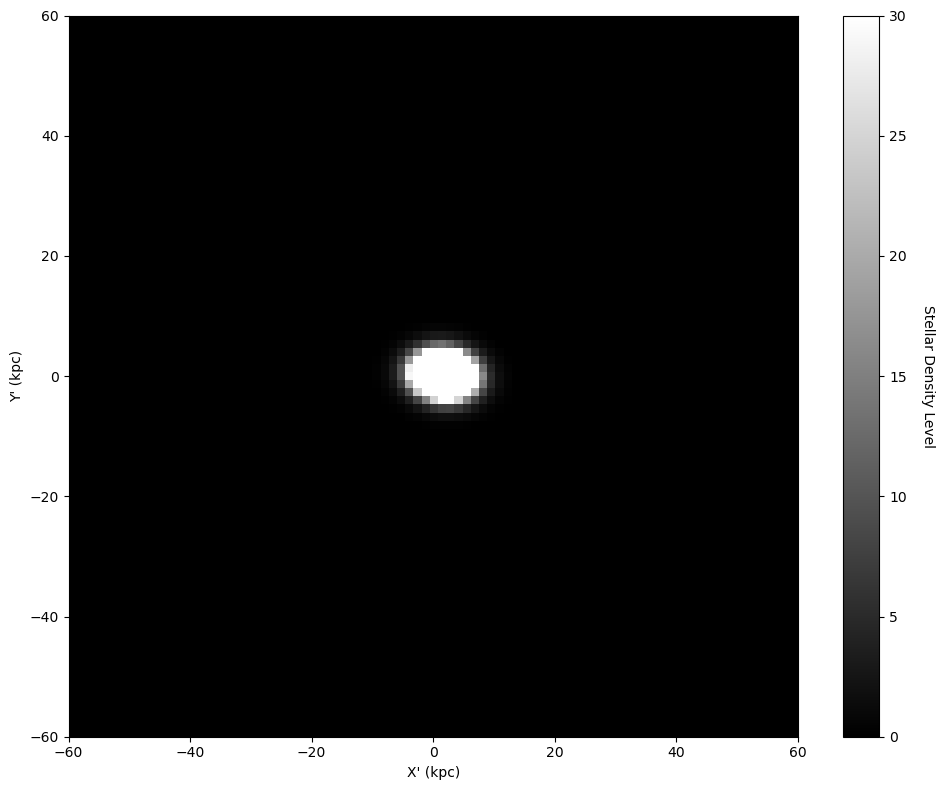

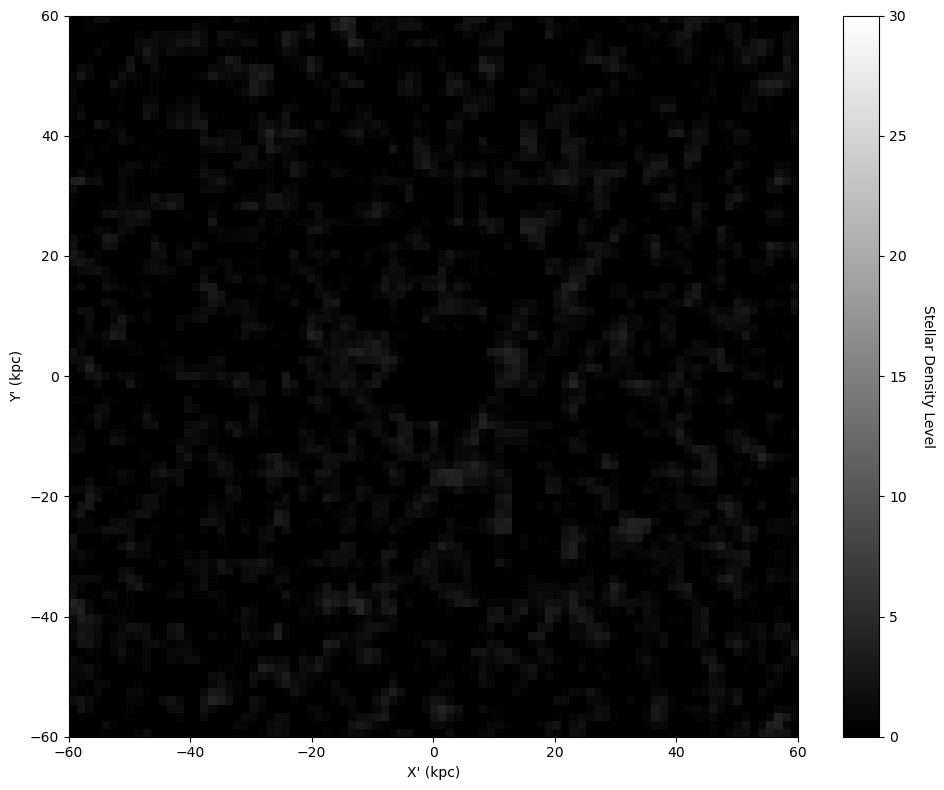

File name: mf_rogue_5_d=58.6_a=287.4_pix=8000.fits
Fitted Parameters:
A  = 3132.2076
h = 1.1930
q = 0.7868
x_offset = 1.2126
y_offset = 0.3538
theta = -0.0821
C  = -0.1263


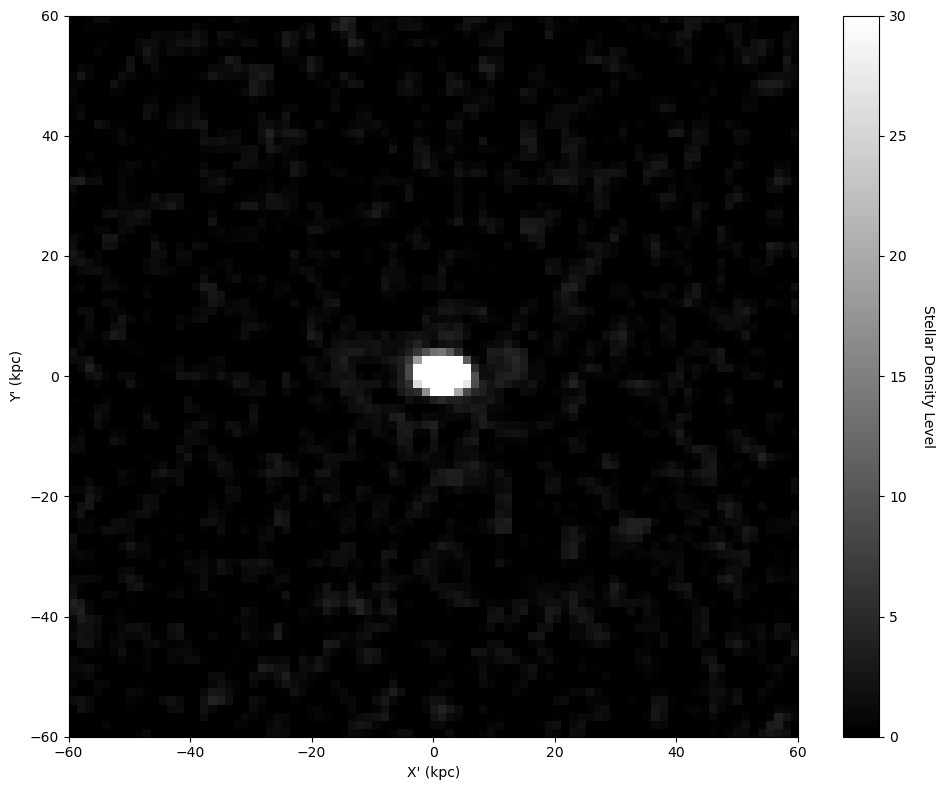

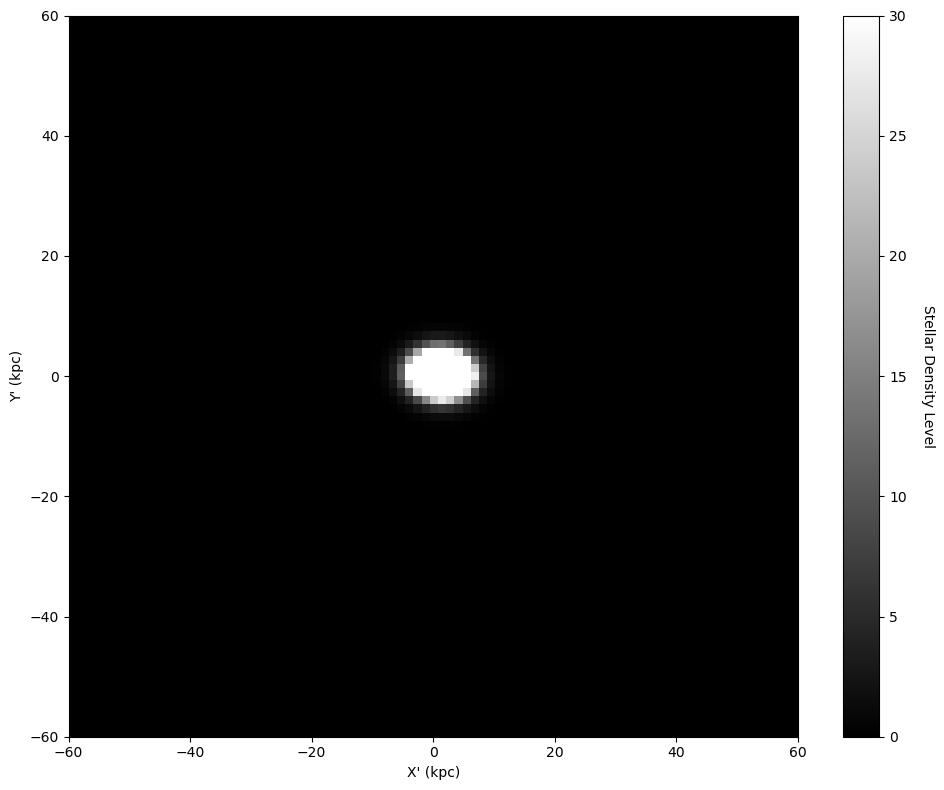

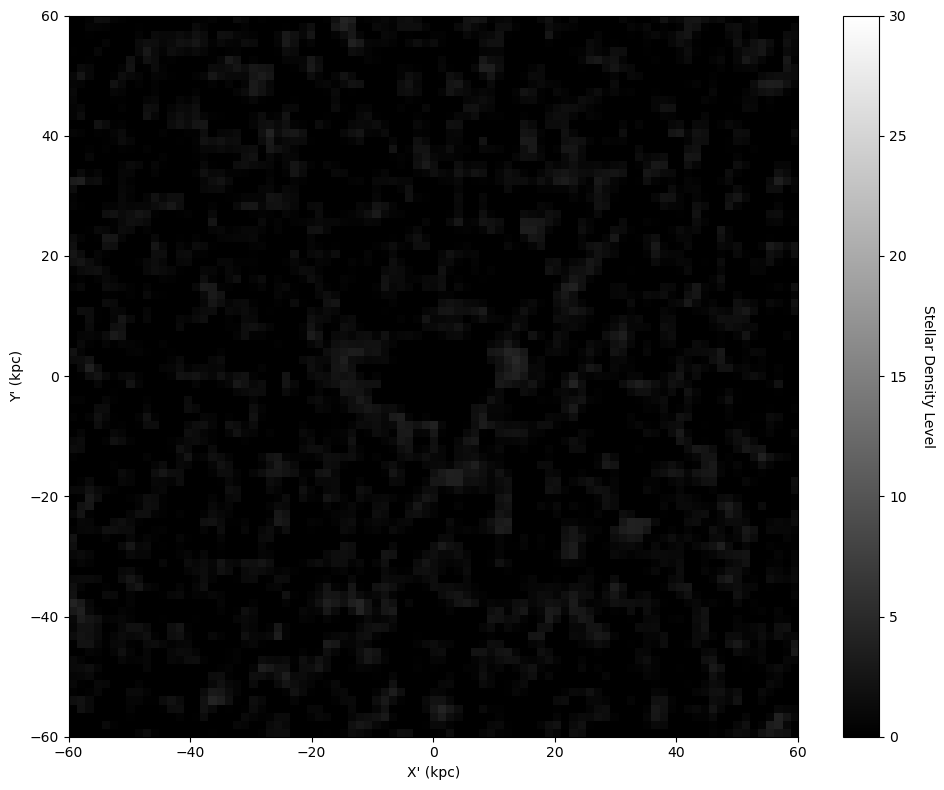

File name: mf_rogue_5_d=61.4_a=149.9_pix=8000.fits
Fitted Parameters:
A  = 3074.7406
h = 1.1354
q = 0.8988
x_offset = 1.2363
y_offset = 0.2861
theta = -0.0104
C  = -0.1512


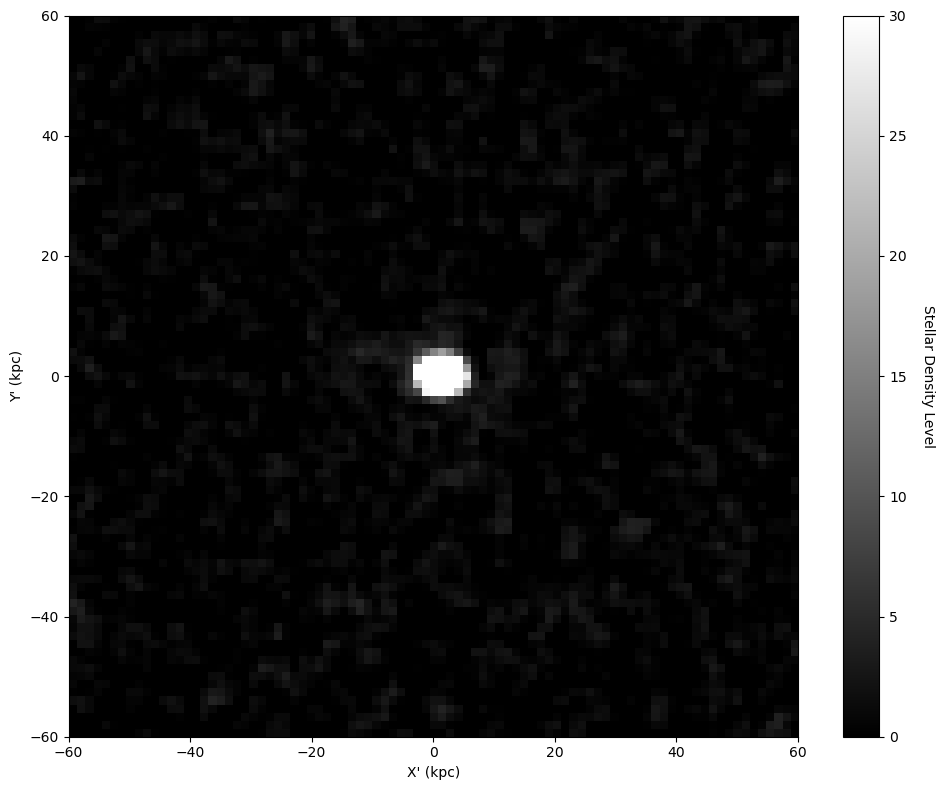

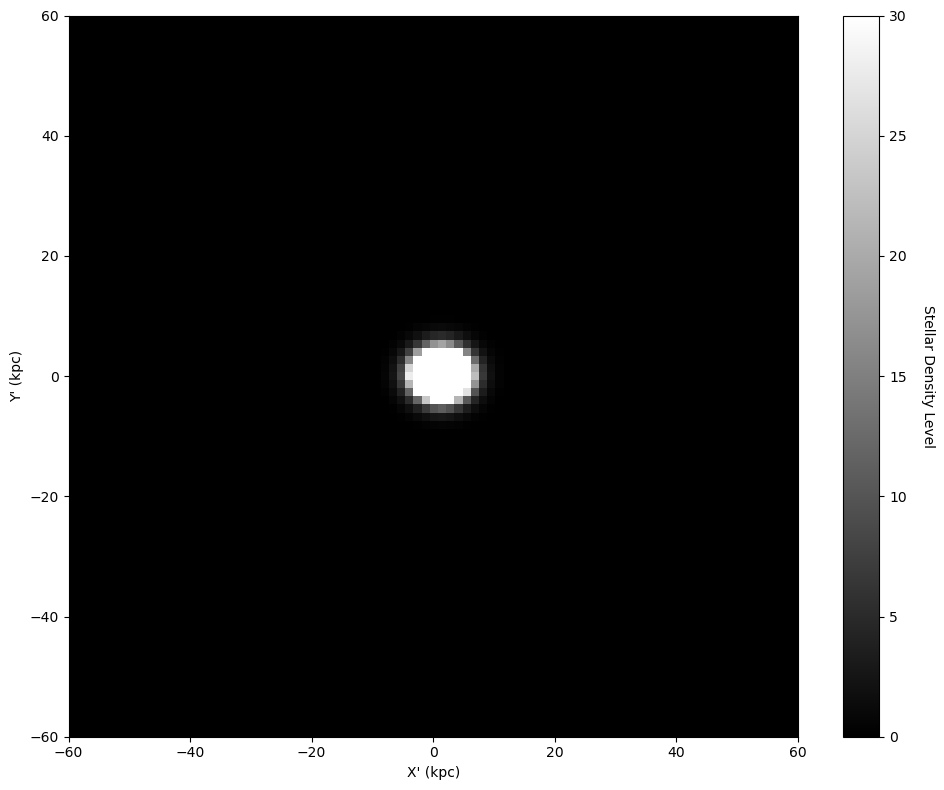

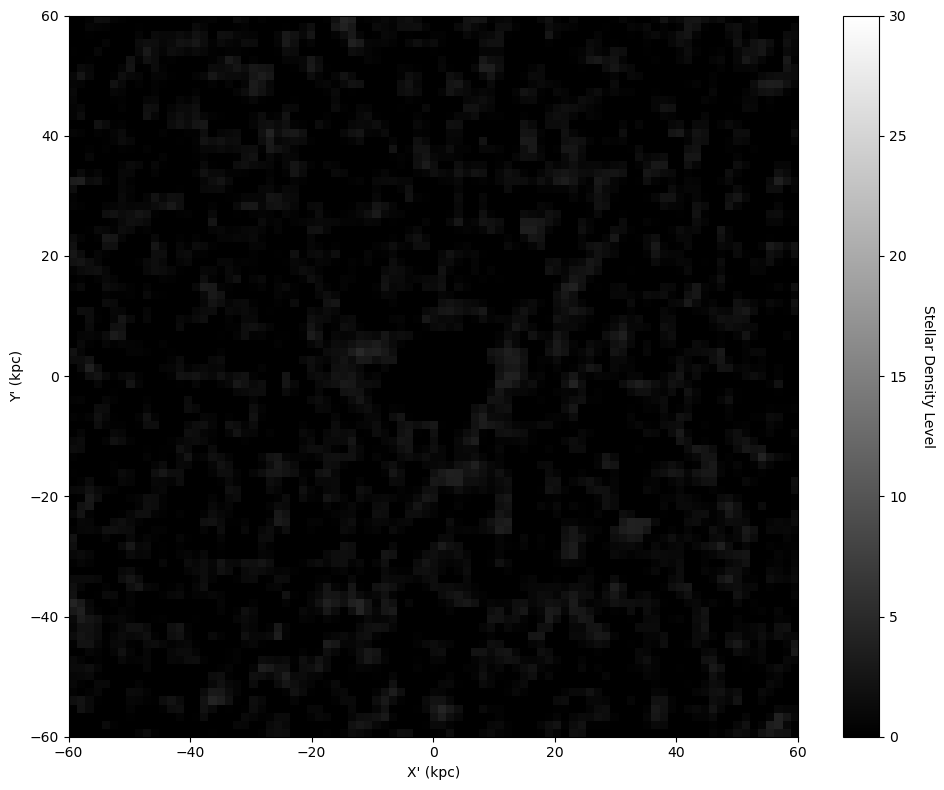

File name: mf_rogue_5_d=64.2_a=12.4_pix=8000.fits
Fitted Parameters:
A  = 3286.9398
h = 1.1311
q = 0.8457
x_offset = 1.4923
y_offset = 0.3446
theta = 0.0970
C  = -0.1426


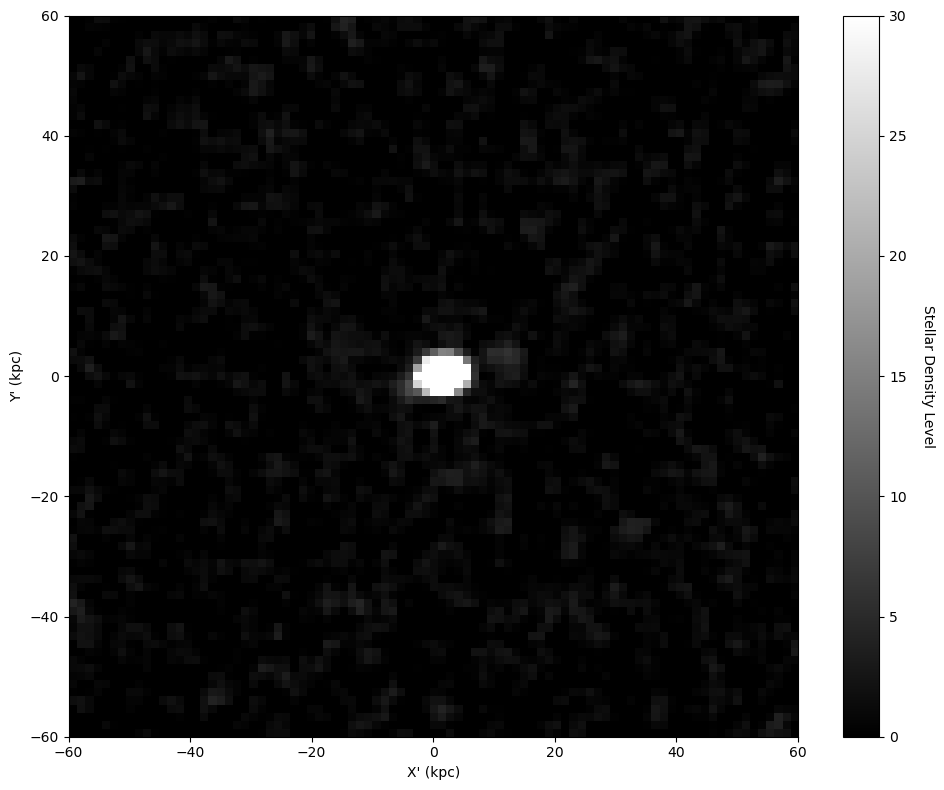

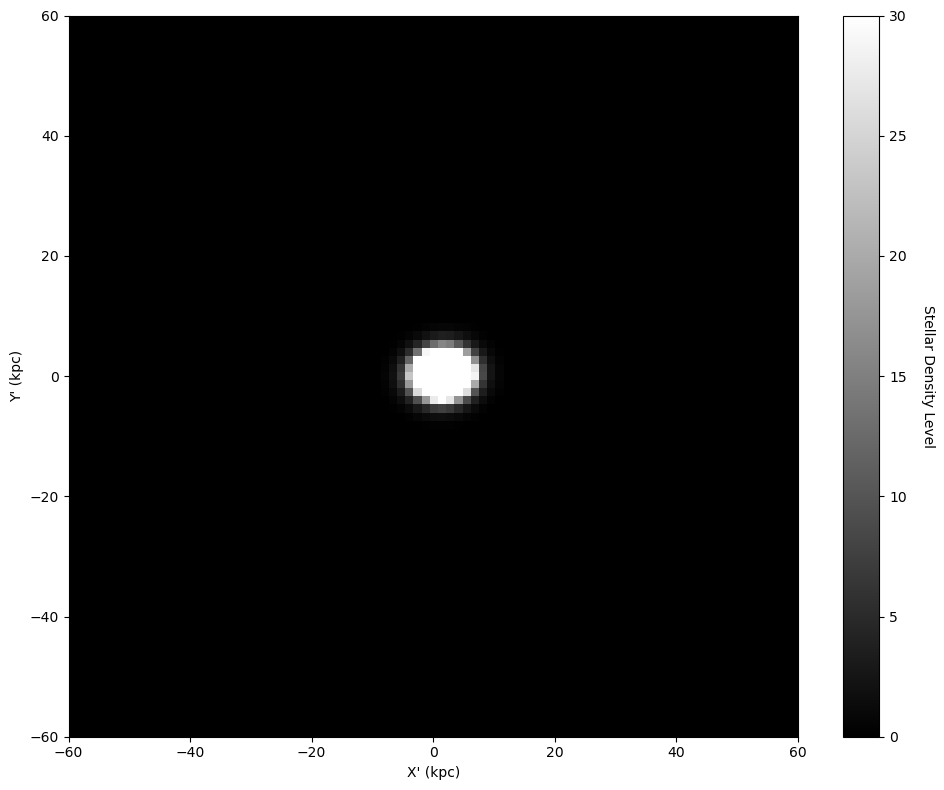

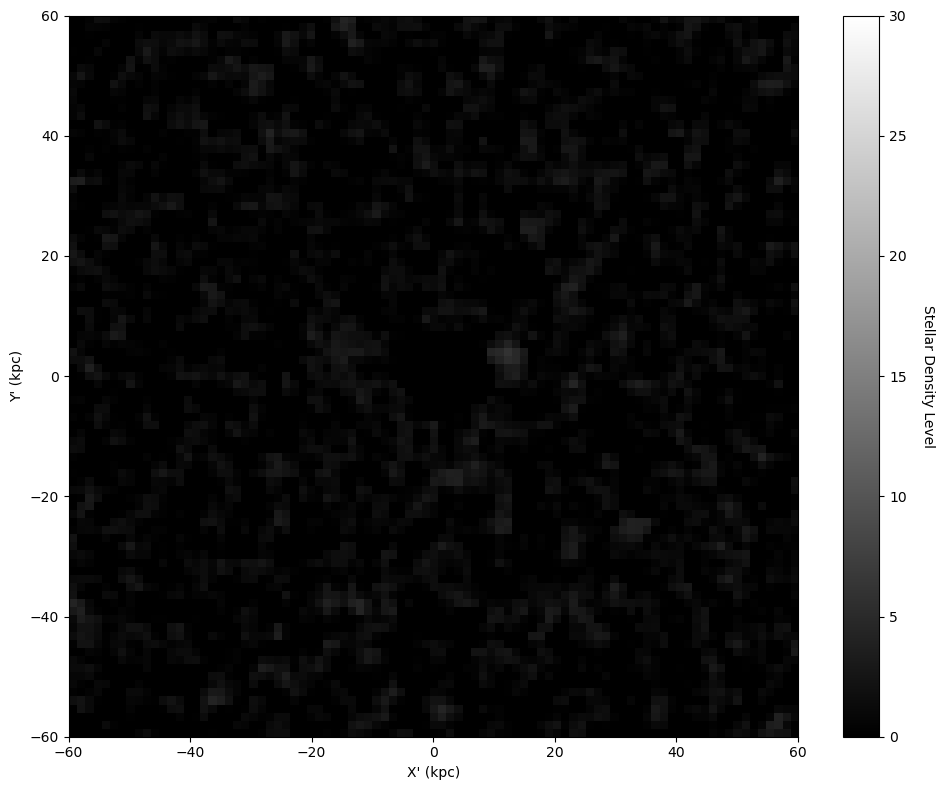

File name: mf_rogue_5_d=67.0_a=234.9_pix=8000.fits
Fitted Parameters:
A  = 3042.7548
h = 1.2644
q = 0.7347
x_offset = 1.1327
y_offset = 0.2656
theta = 0.1983
C  = -0.1453


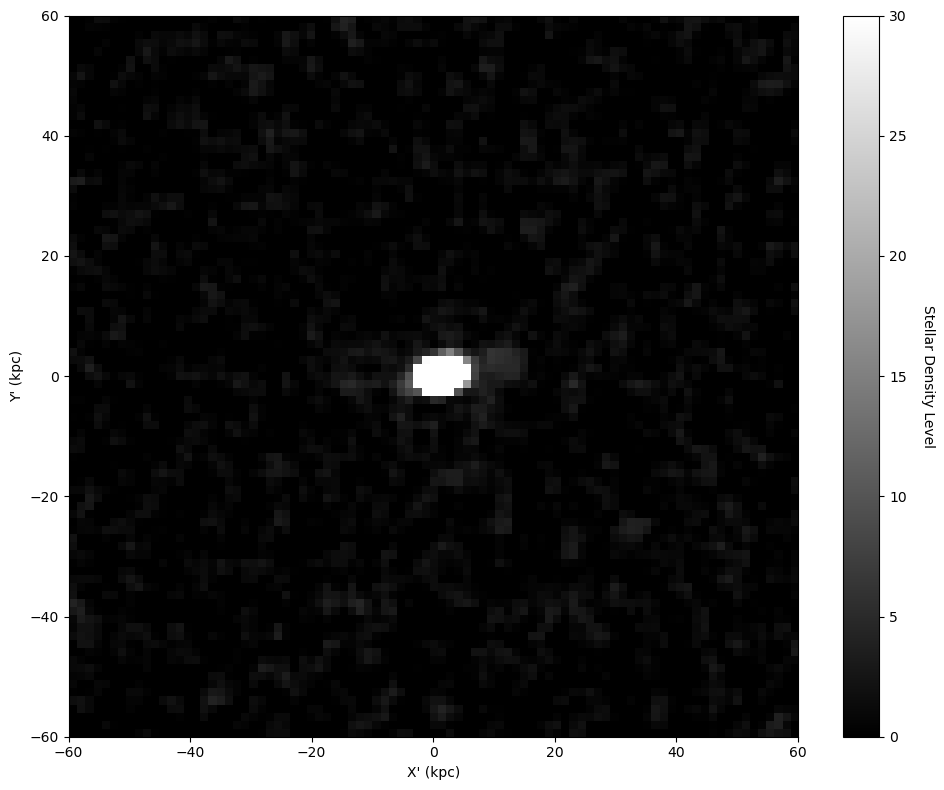

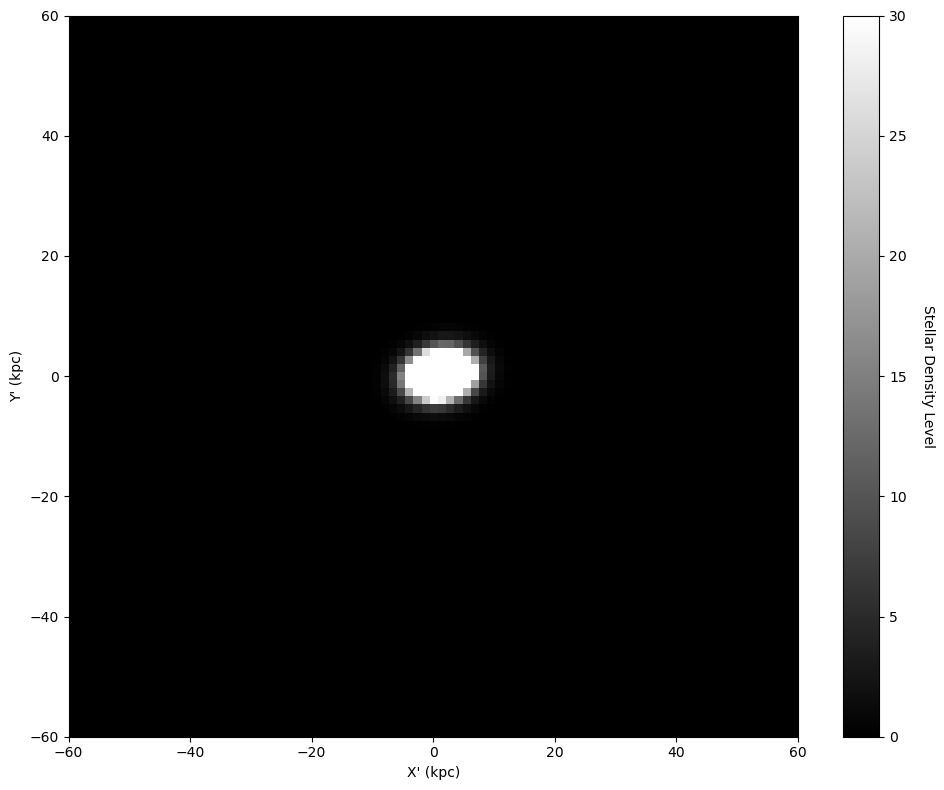

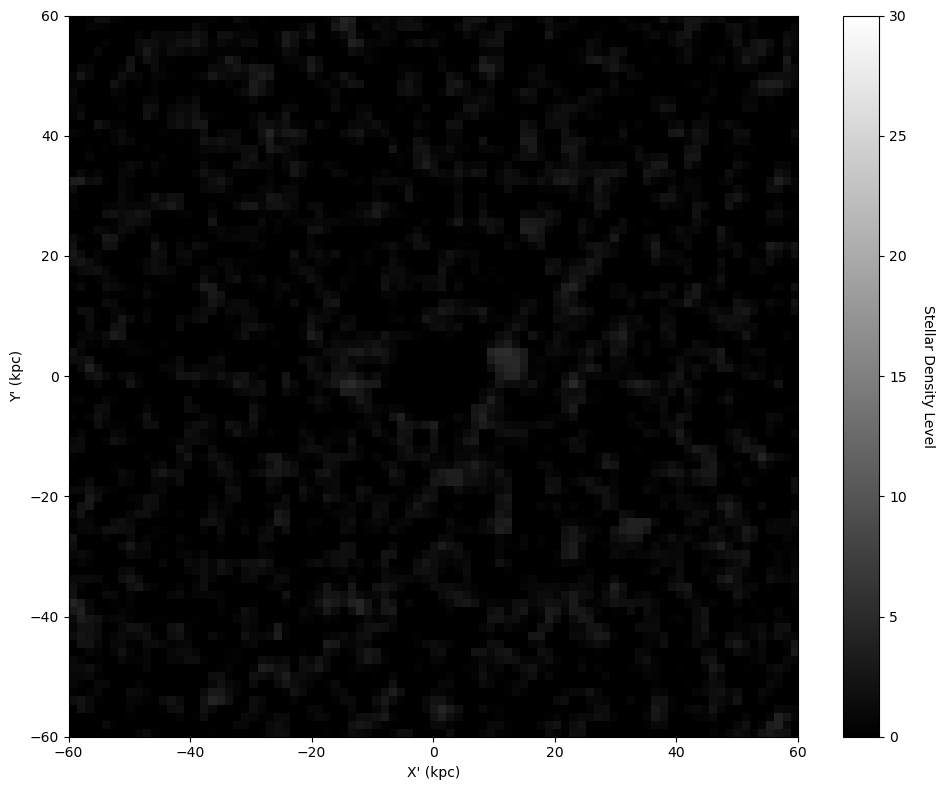

File name: mf_rogue_5_d=69.6_a=97.4_pix=8000.fits
Fitted Parameters:
A  = 2990.9530
h = 1.2603
q = 0.7475
x_offset = 1.4279
y_offset = 0.2882
theta = -0.1819
C  = -0.1496


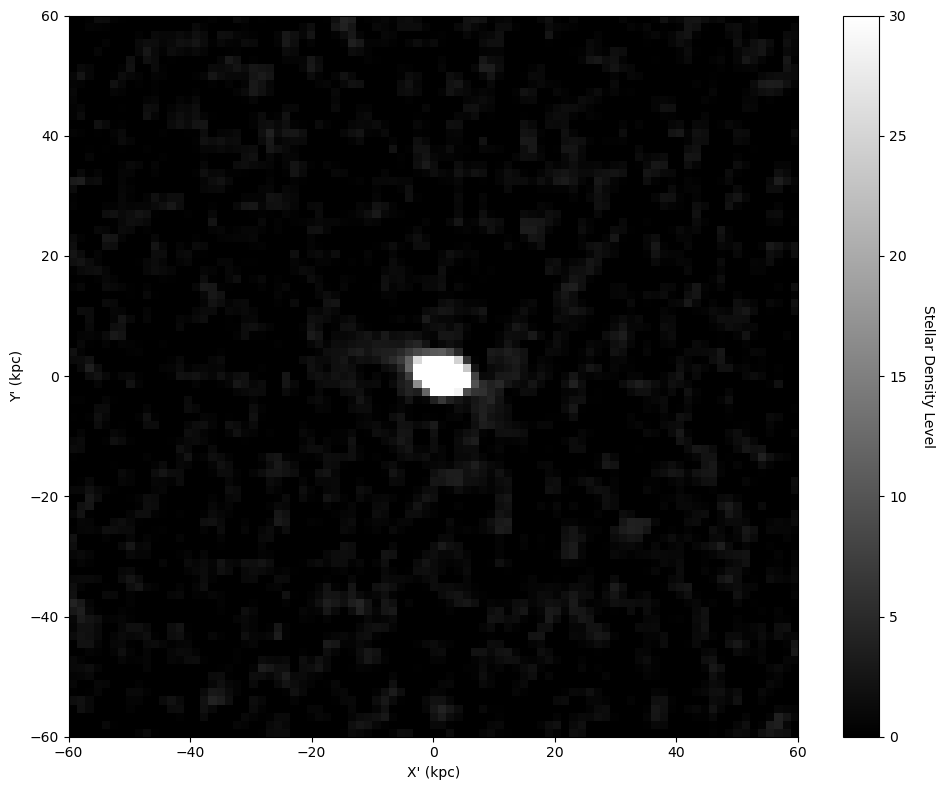

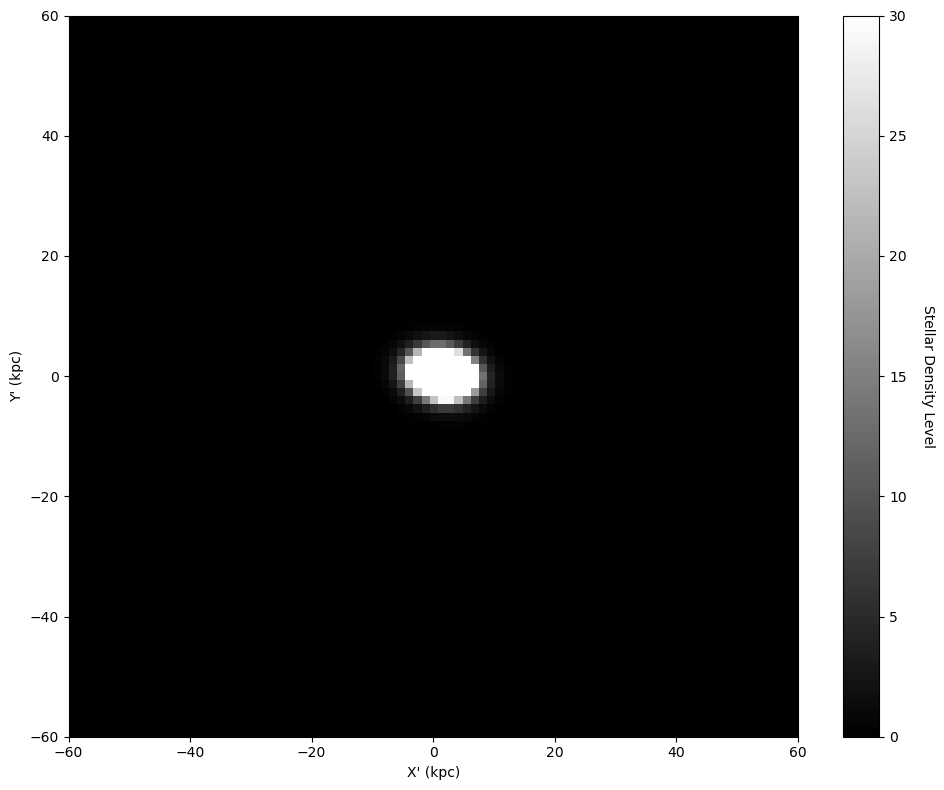

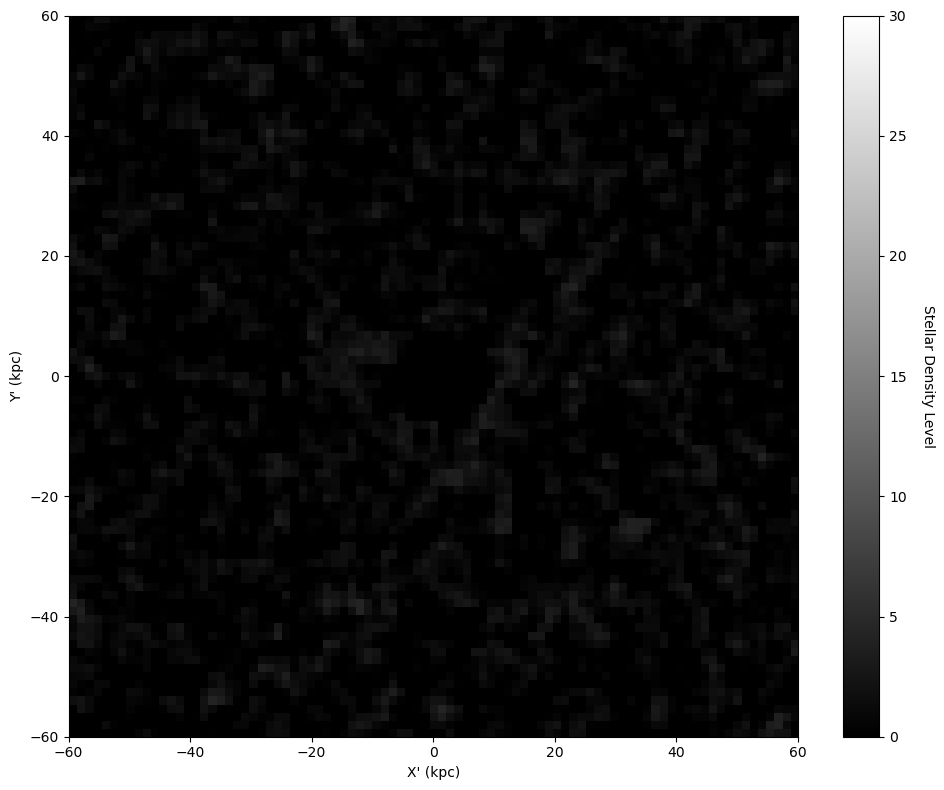

File name: mf_rogue_5_d=72.3_a=319.9_pix=8000.fits
Fitted Parameters:
A  = 3447.8744
h = 1.1218
q = 0.8220
x_offset = 1.1734
y_offset = 0.3115
theta = 0.0098
C  = -0.1434


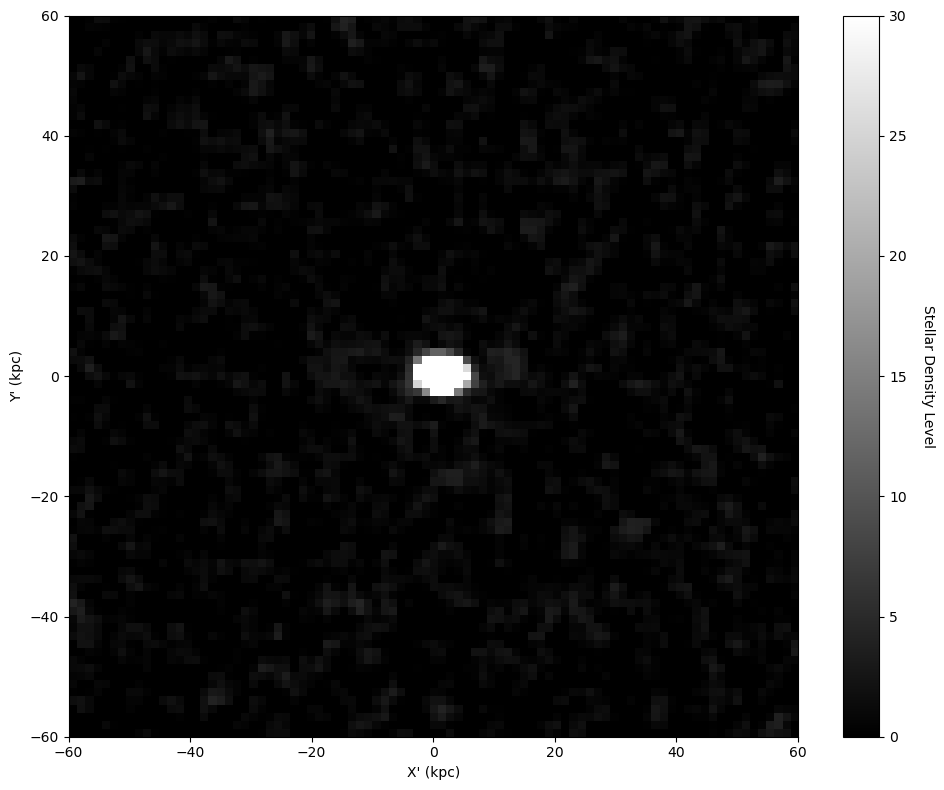

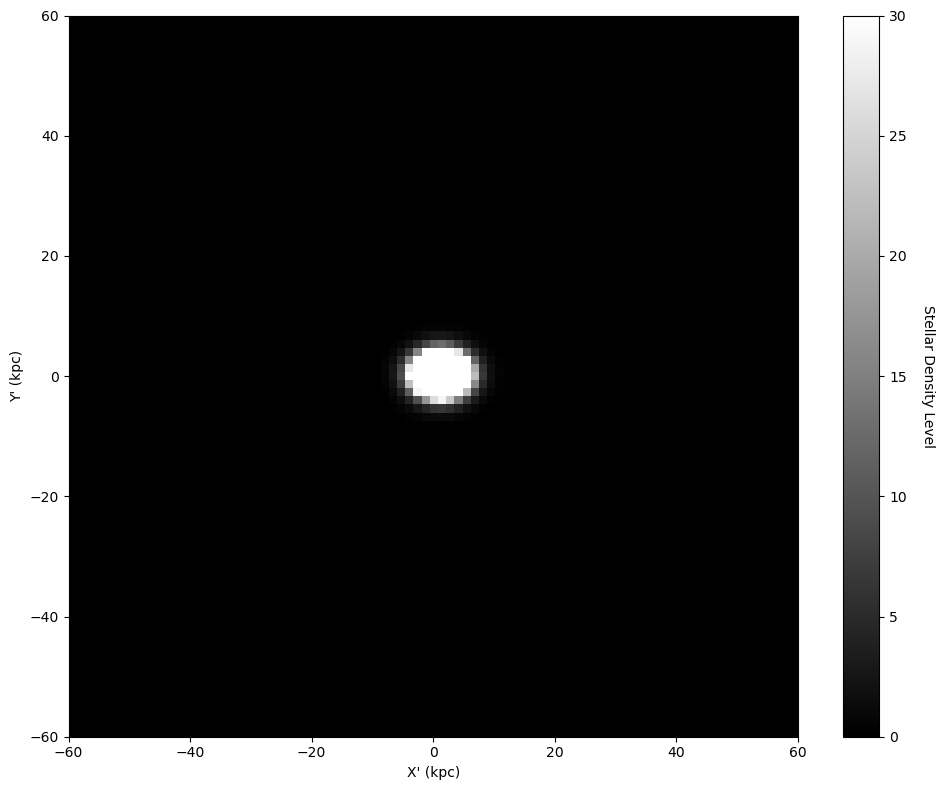

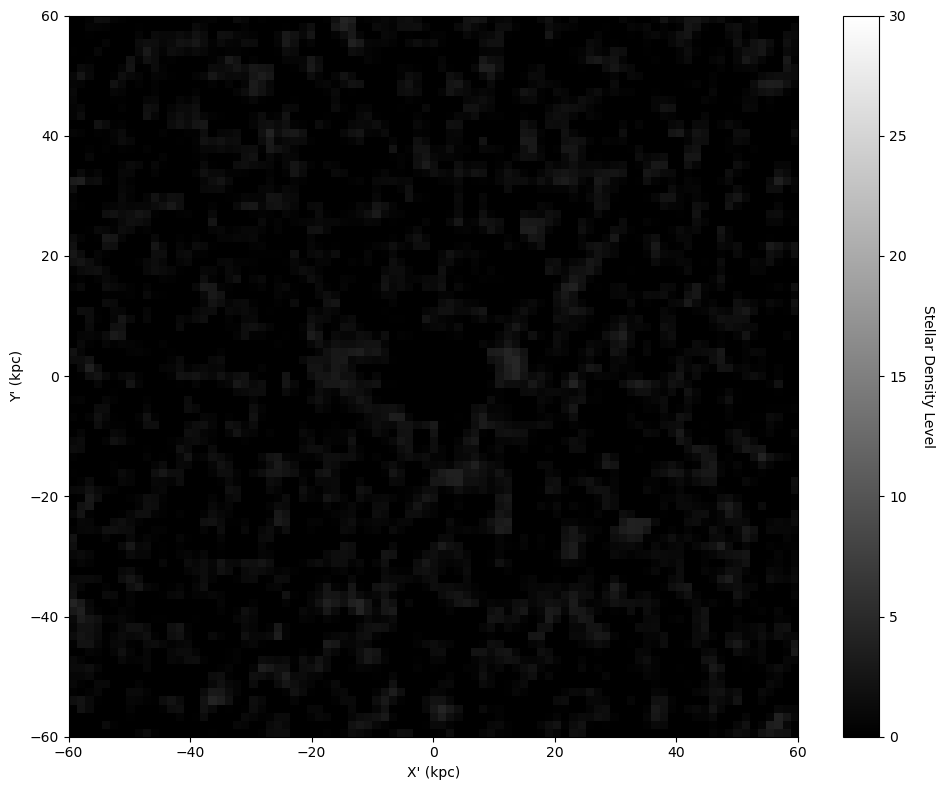

File name: mf_rogue_5_d=74.9_a=182.4_pix=8000.fits
Fitted Parameters:
A  = 3394.7075
h = 1.1089
q = 0.8515
x_offset = 1.1095
y_offset = 0.2527
theta = 0.3294
C  = -0.1474


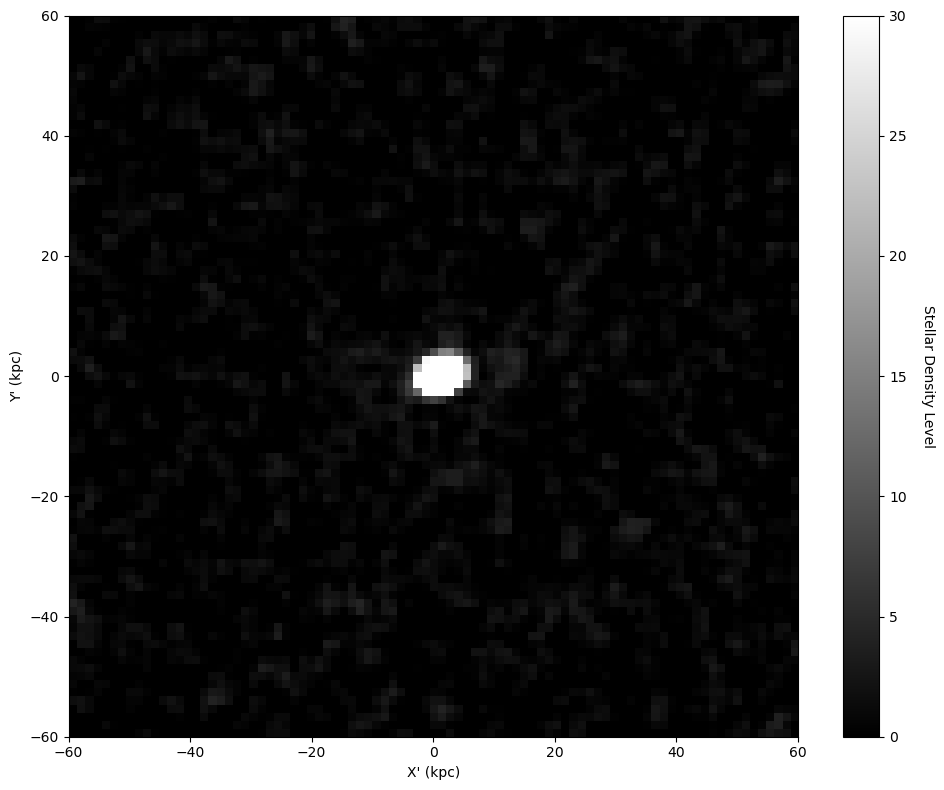

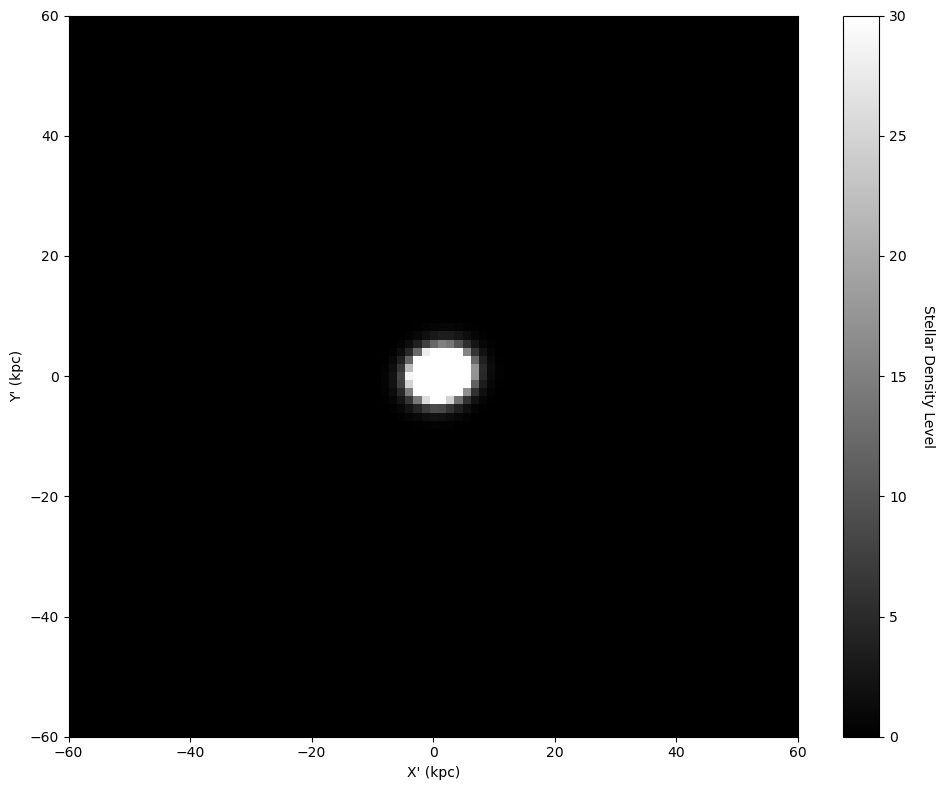

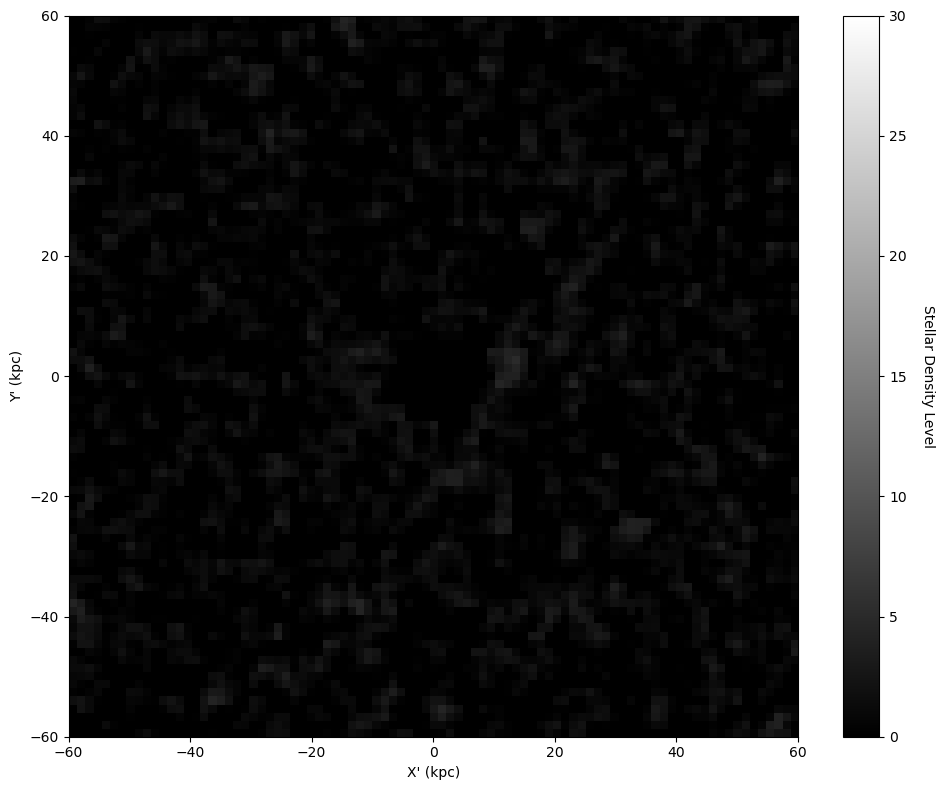

File name: mf_rogue_5_d=77.4_a=44.9_pix=8000.fits
Fitted Parameters:
A  = 3107.0894
h = 1.2602
q = 0.7178
x_offset = 1.5749
y_offset = 0.2724
theta = -0.0497
C  = -0.1448


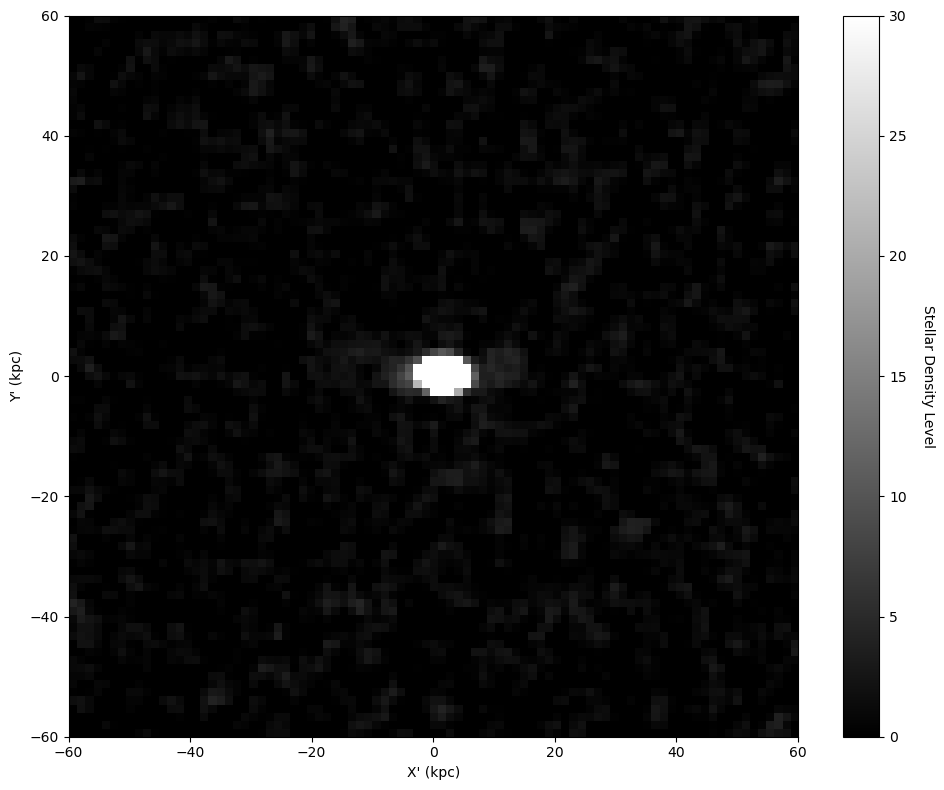

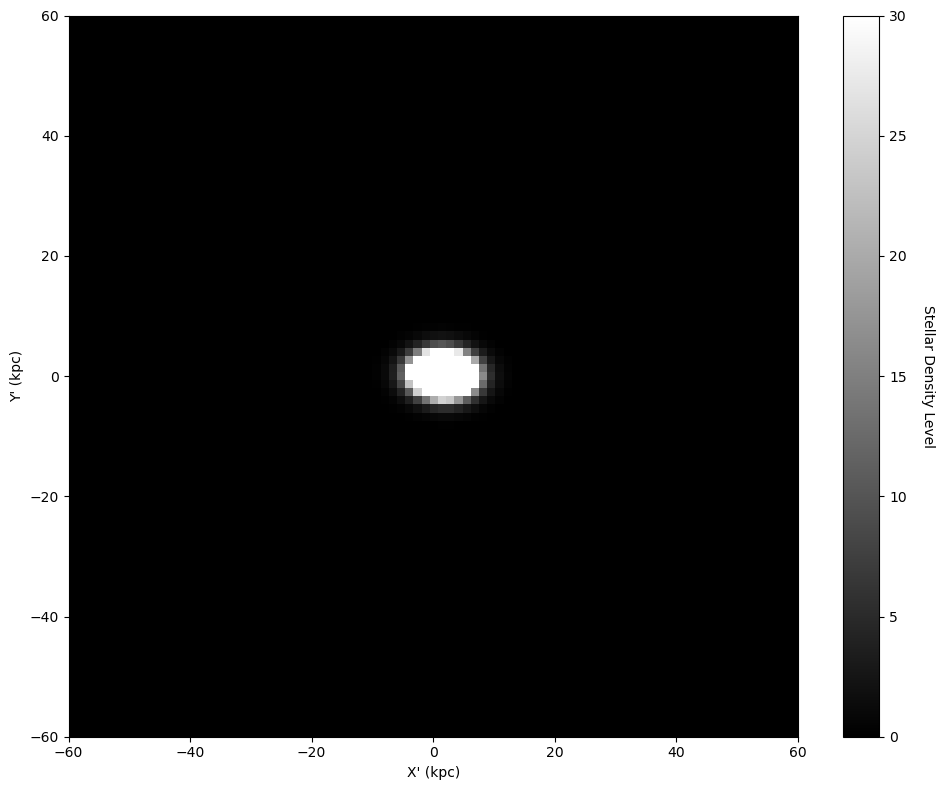

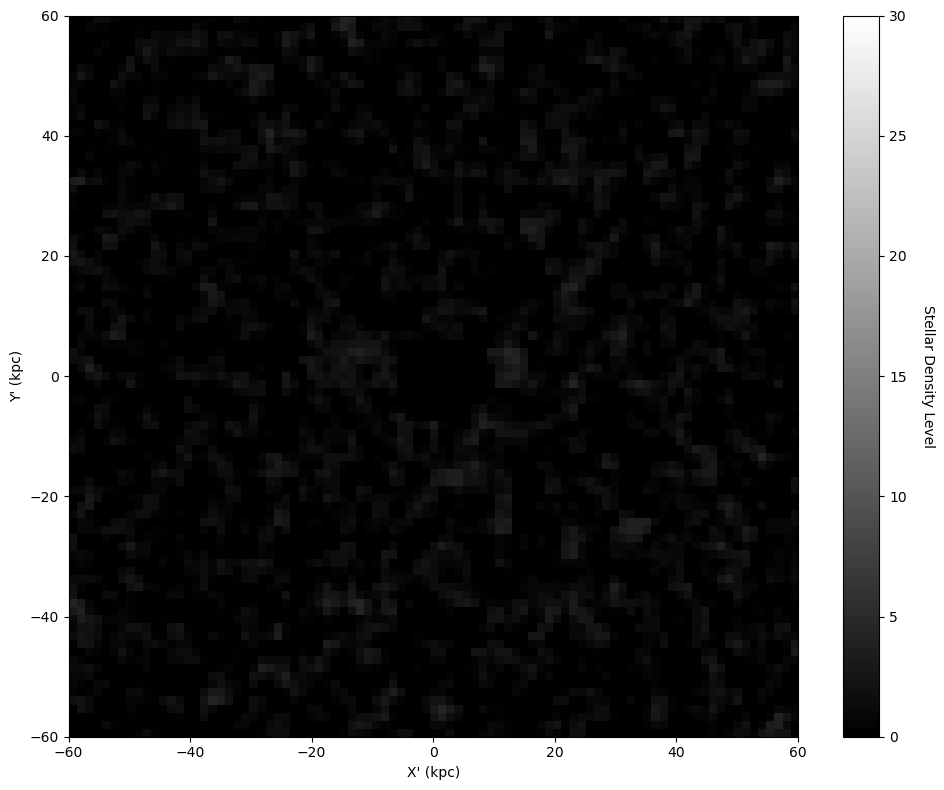

File name: mf_rogue_5_d=80.0_a=267.4_pix=8000.fits
Fitted Parameters:
A  = 3124.5268
h = 1.2583
q = 0.7168
x_offset = 1.1127
y_offset = 0.2703
theta = 0.0597
C  = -0.1407


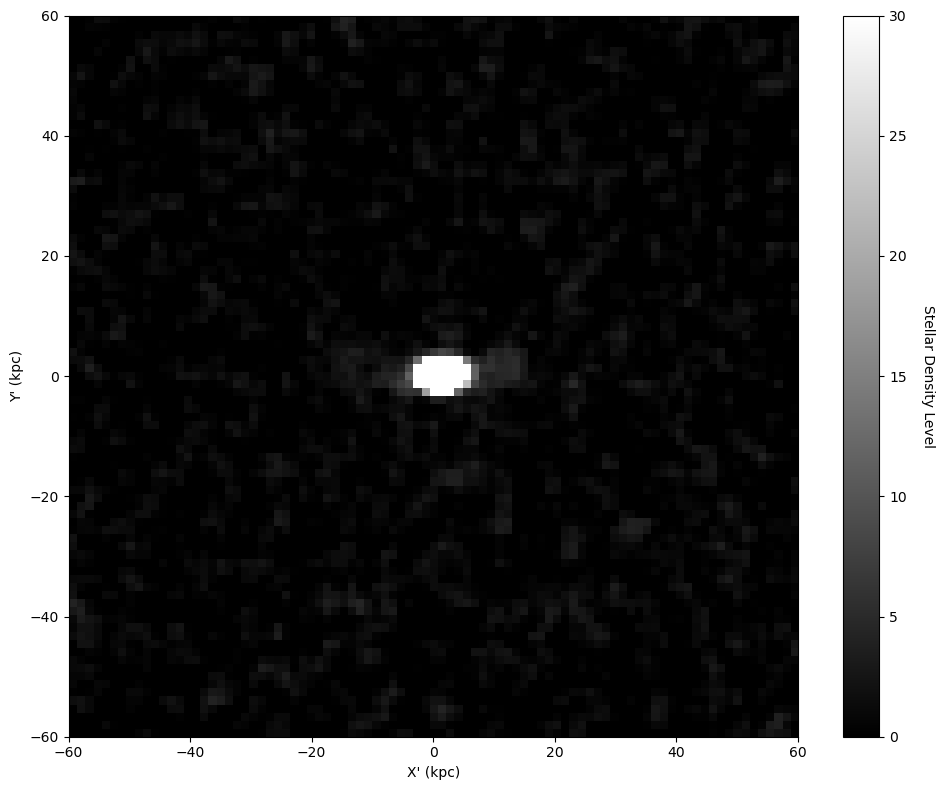

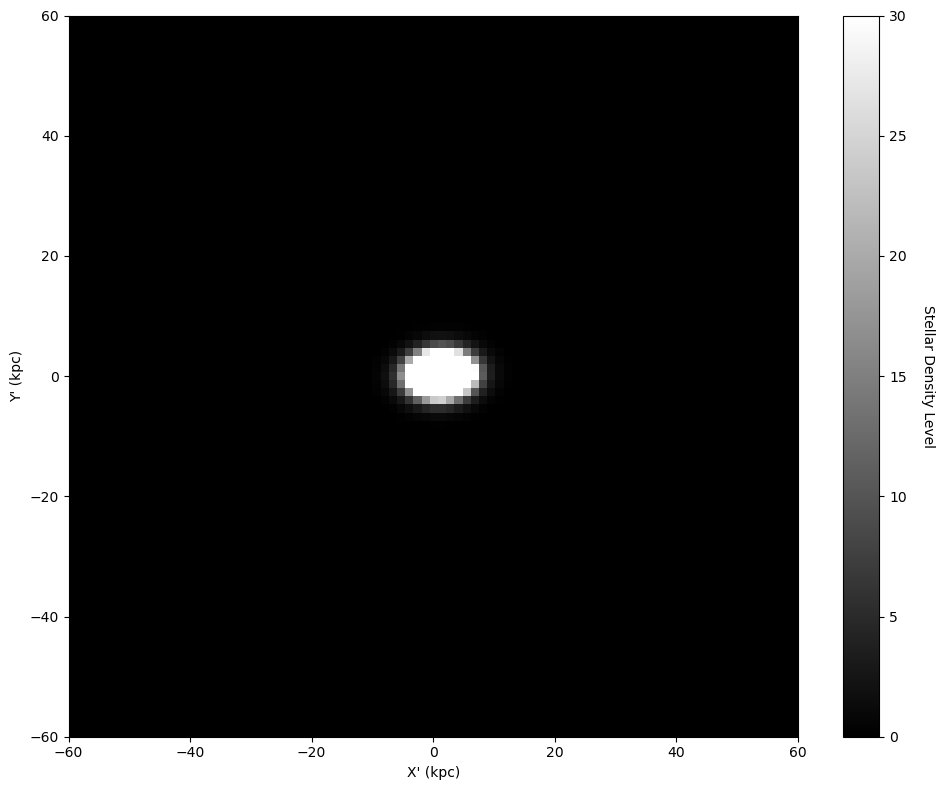

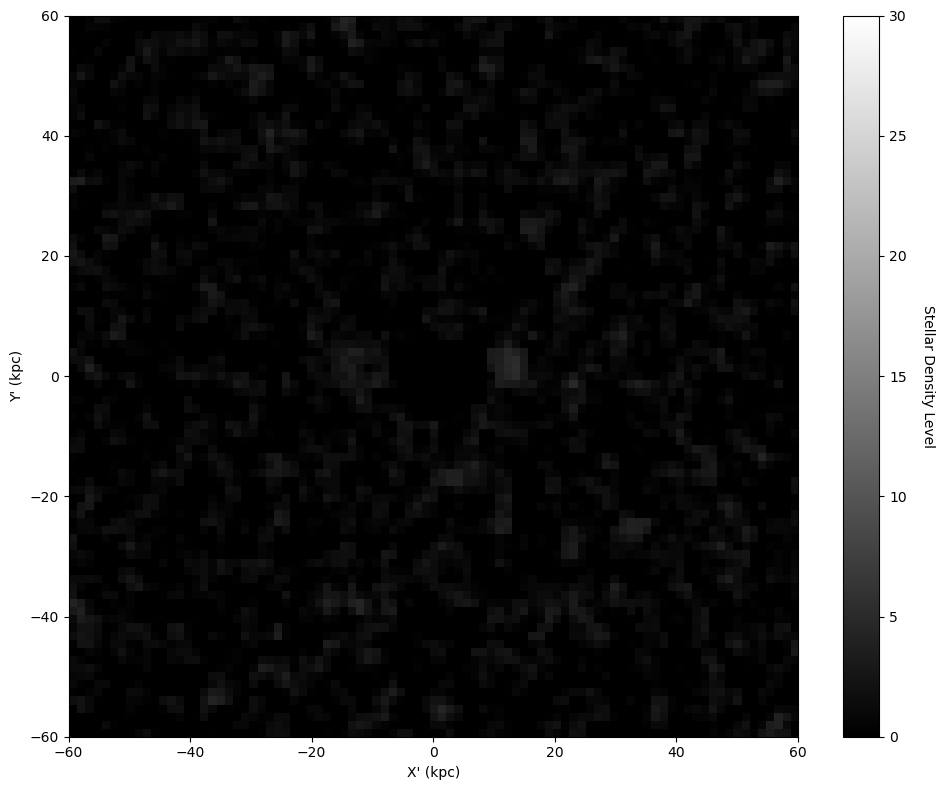

File name: mf_rogue_5_d=82.5_a=129.8_pix=8000.fits
Fitted Parameters:
A  = 3304.0310
h = 1.1653
q = 0.7845
x_offset = 1.1150
y_offset = 0.2474
theta = 0.0525
C  = -0.1469


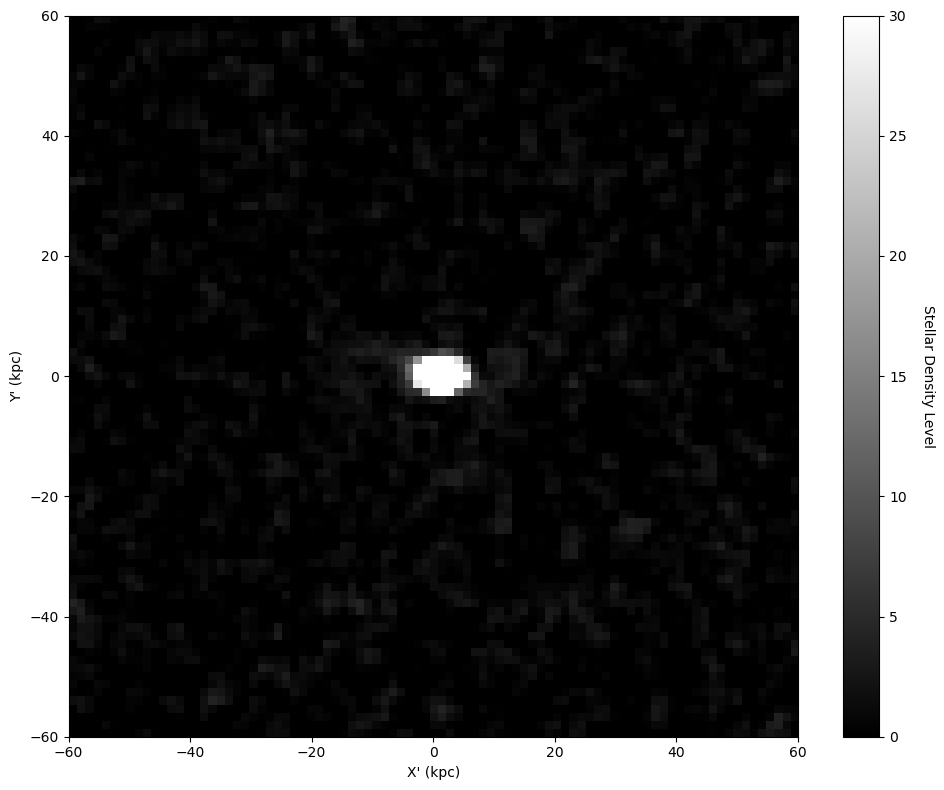

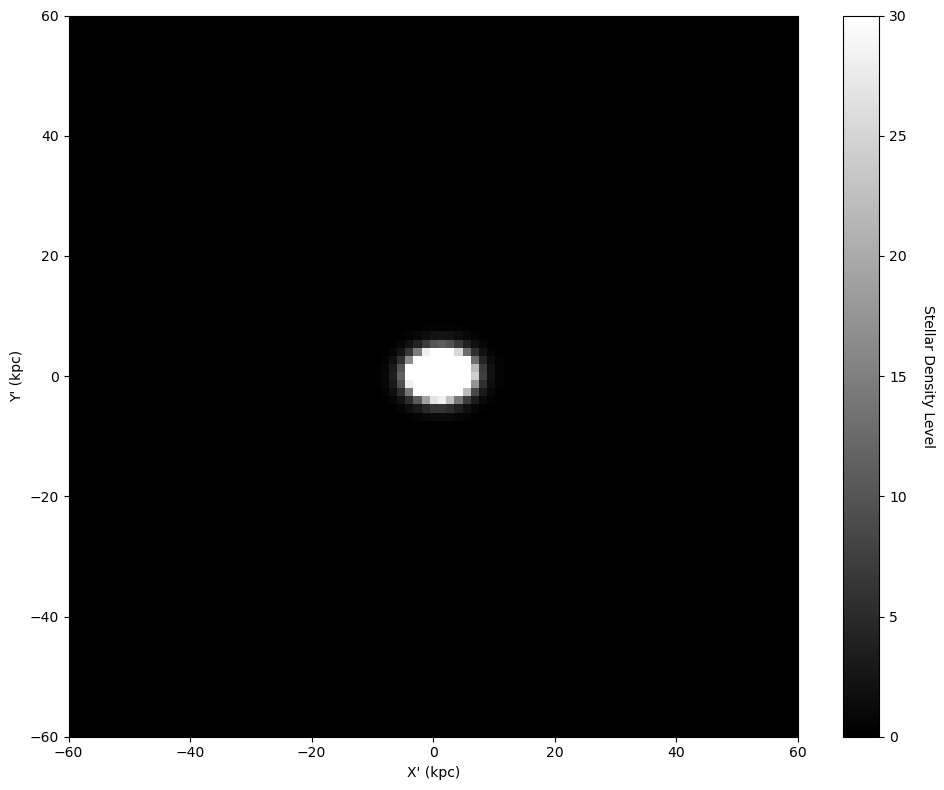

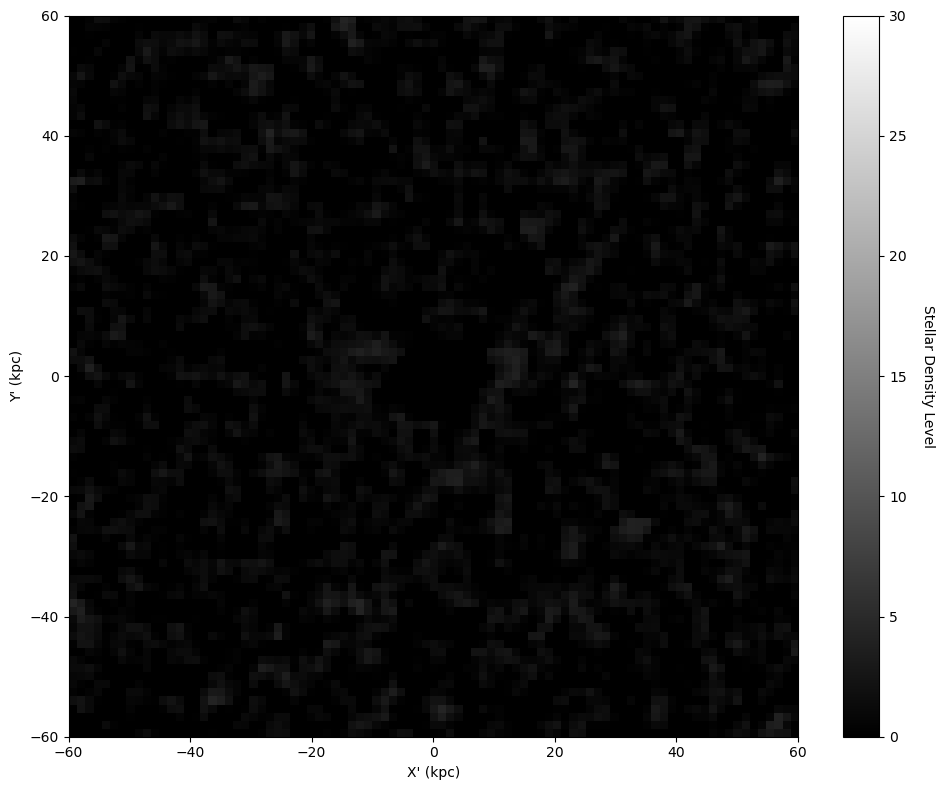

File name: mf_rogue_5_d=85.0_a=352.3_pix=8000.fits
Fitted Parameters:
A  = 3493.7651
h = 1.1381
q = 0.7891
x_offset = 1.2902
y_offset = 0.3023
theta = 0.0114
C  = -0.1513


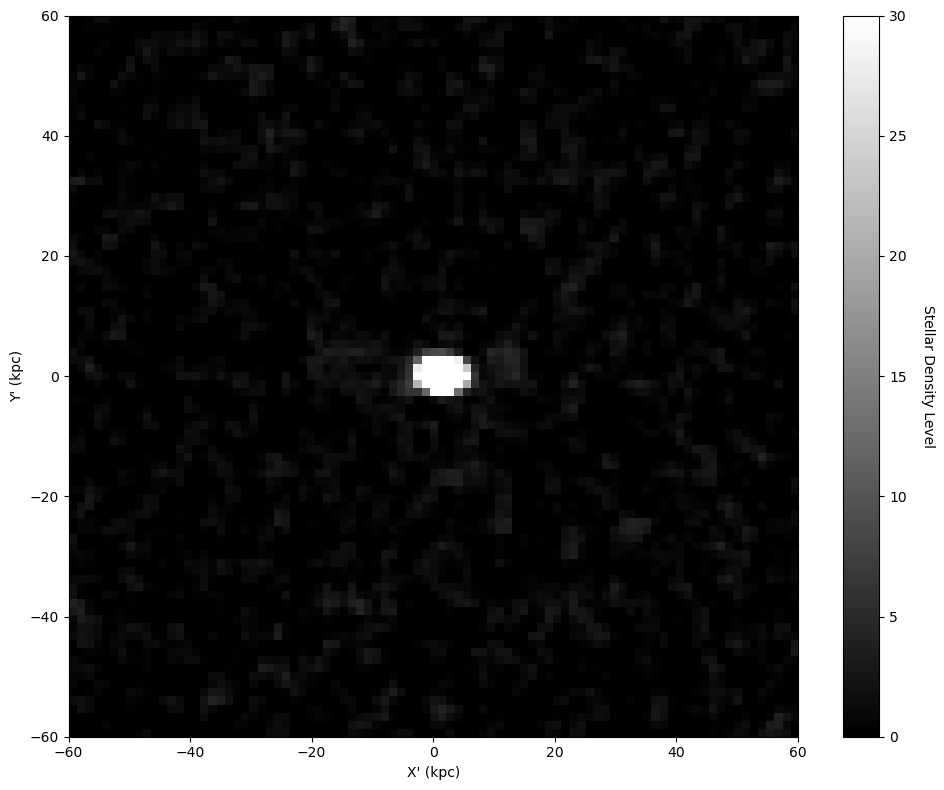

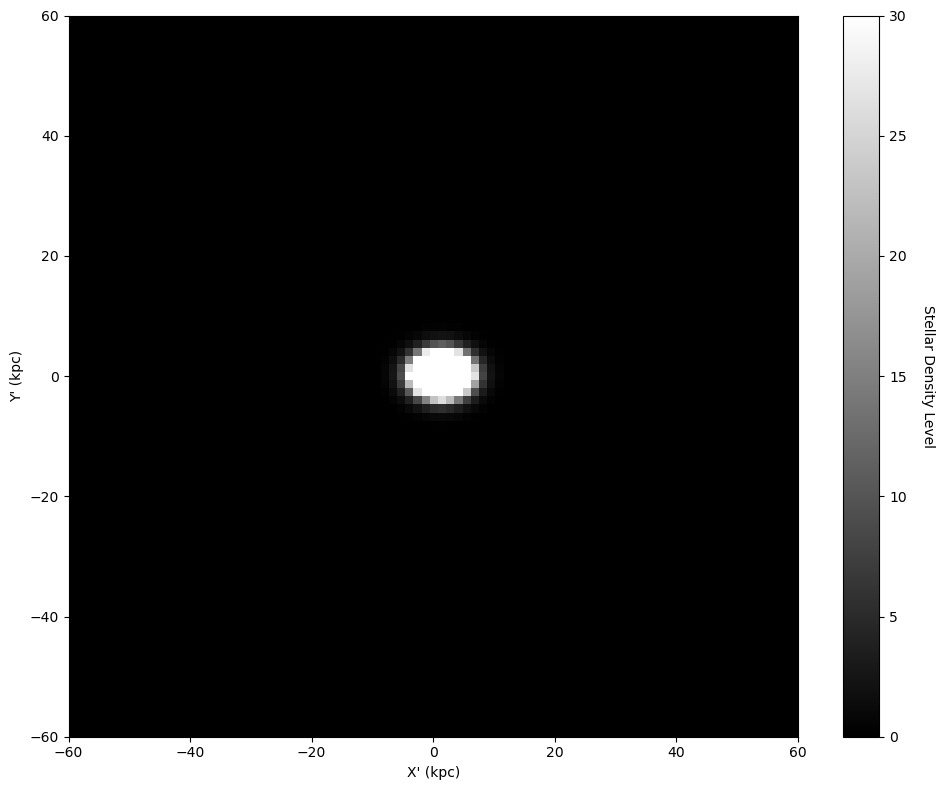

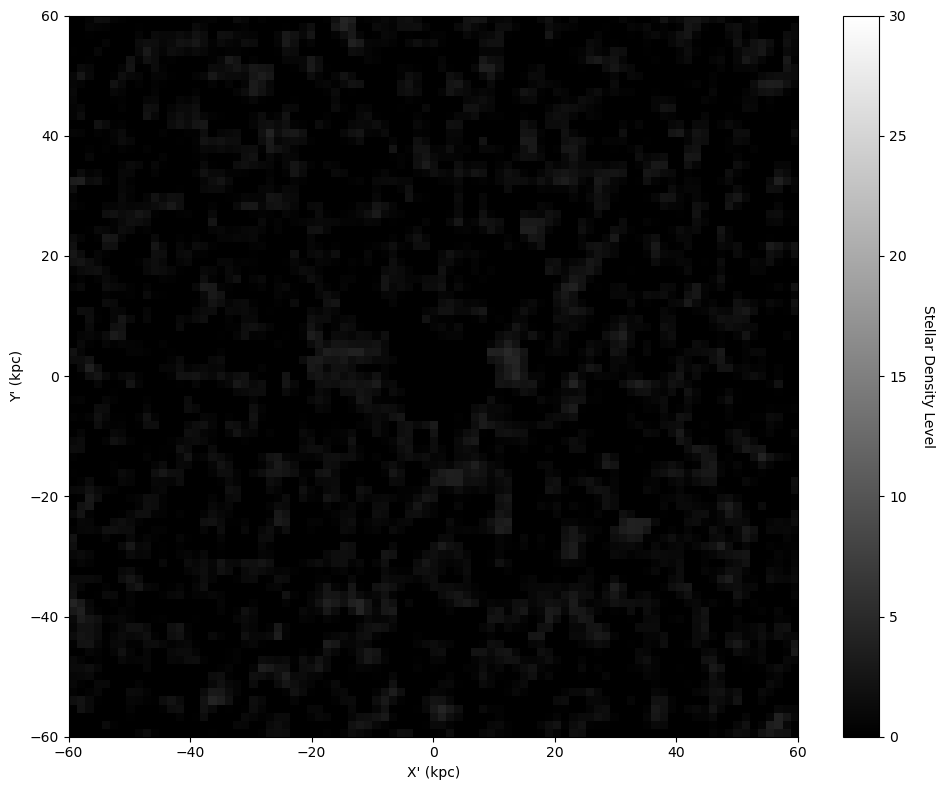

File name: mf_rogue_5_d=87.5_a=214.8_pix=8000.fits
Fitted Parameters:
A  = 3244.2651
h = 1.2071
q = 0.7494
x_offset = 1.1018
y_offset = 0.2519
theta = 0.1675
C  = -0.1425


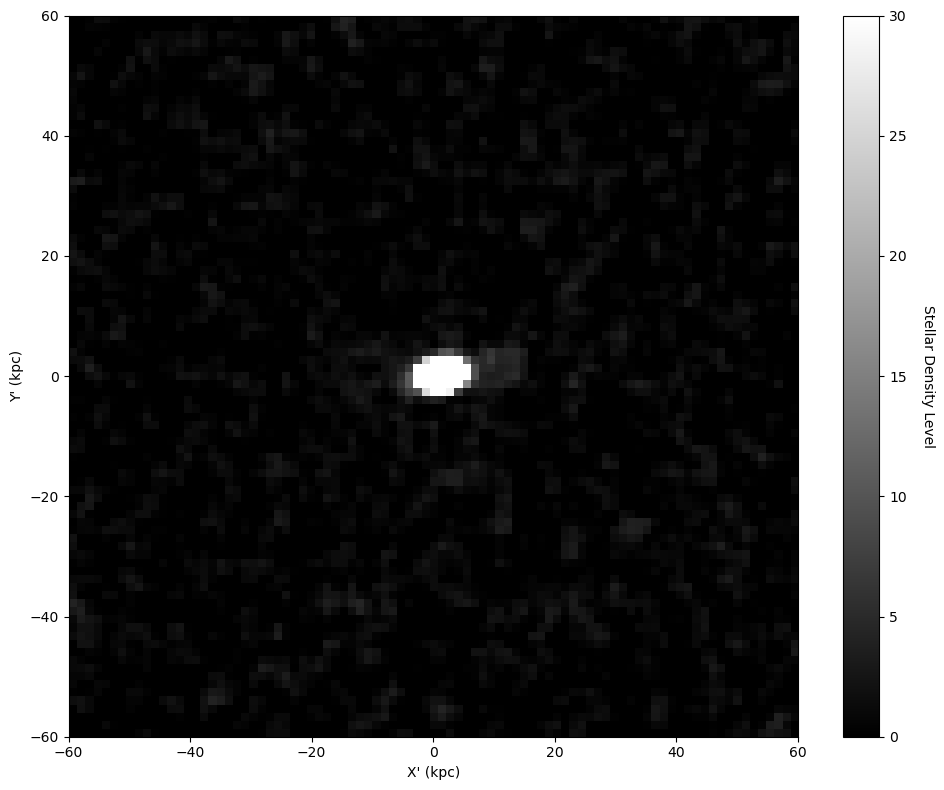

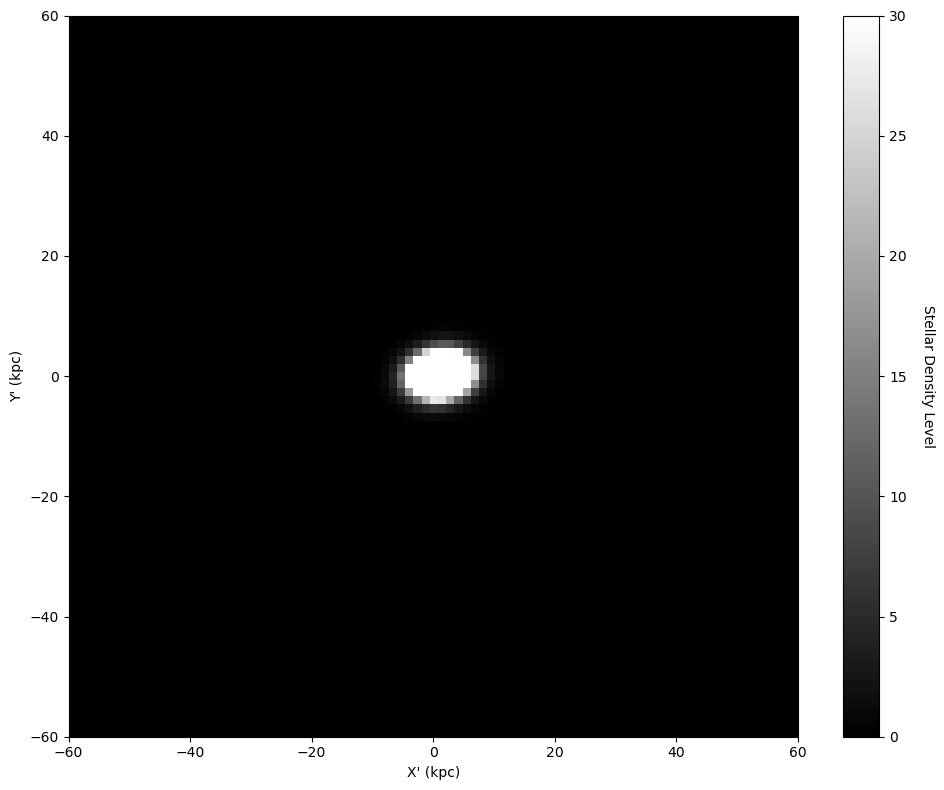

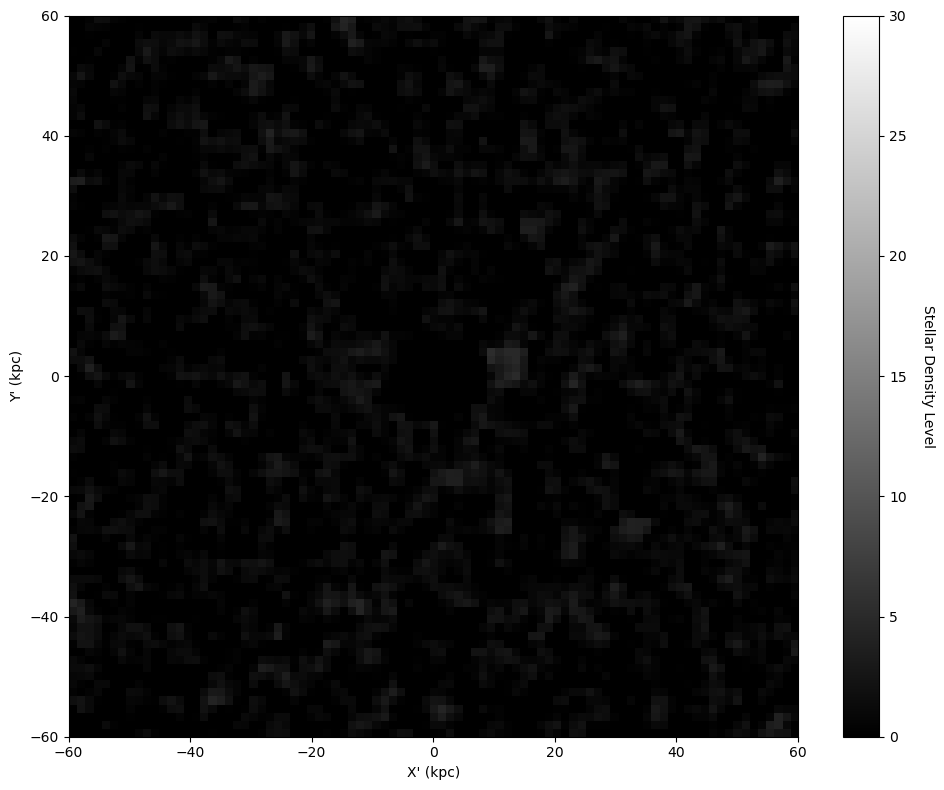

File name: mf_rogue_5_d=90.0_a=77.3_pix=8000.fits
Fitted Parameters:
A  = 3084.5853
h = 1.3102
q = 0.6766
x_offset = 1.4428
y_offset = 0.2944
theta = -0.0370
C  = -0.1500


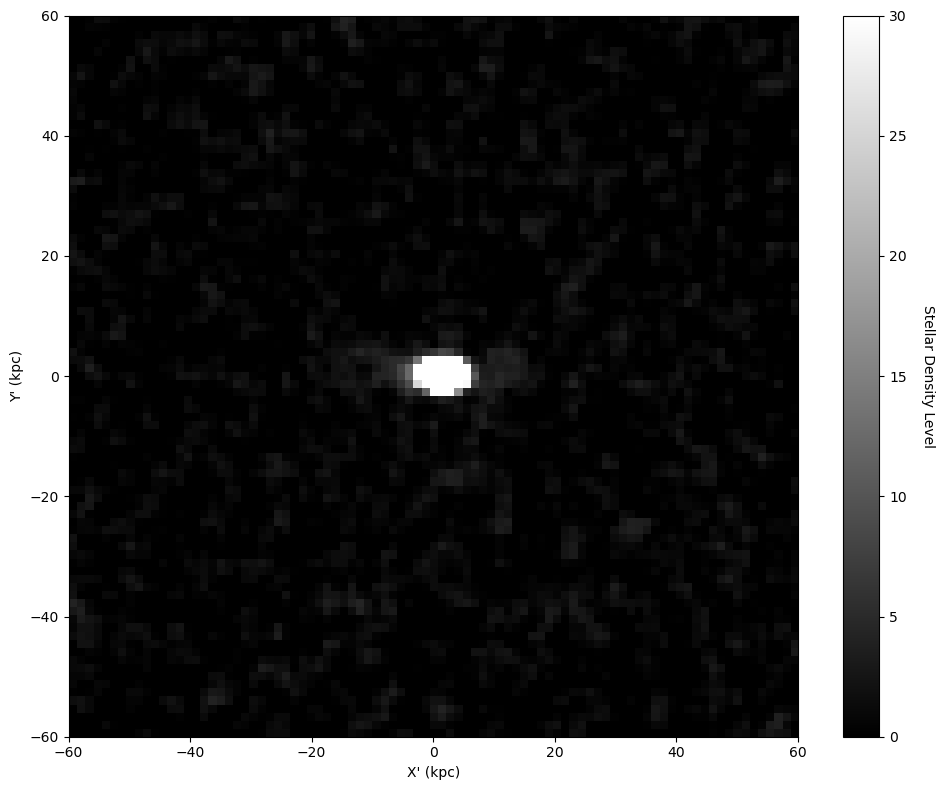

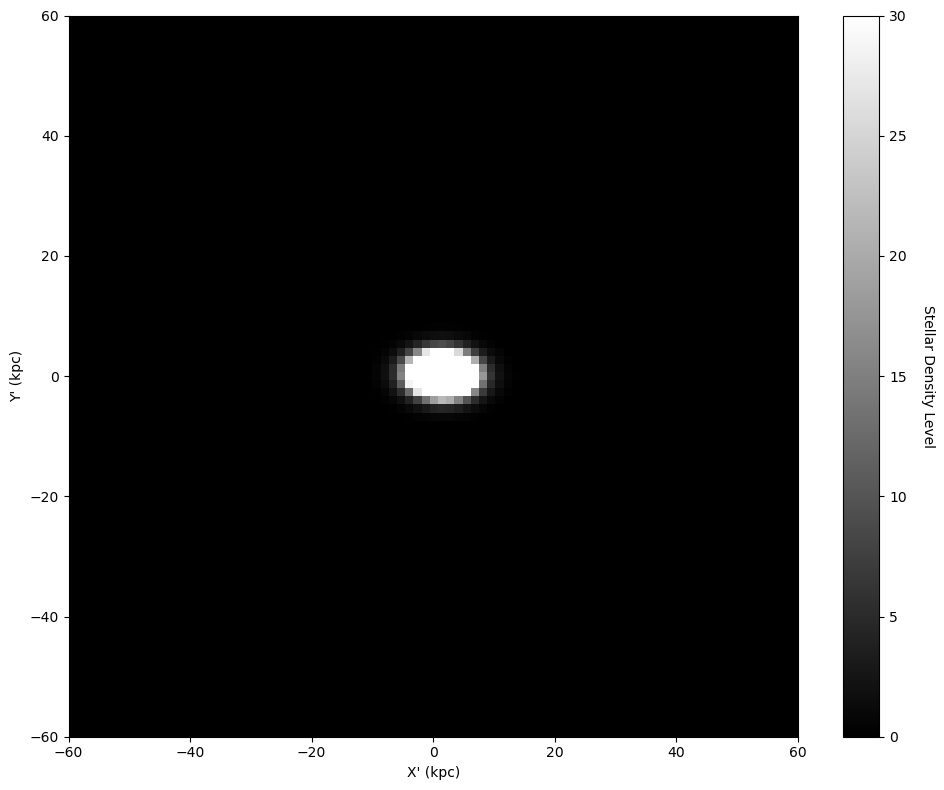

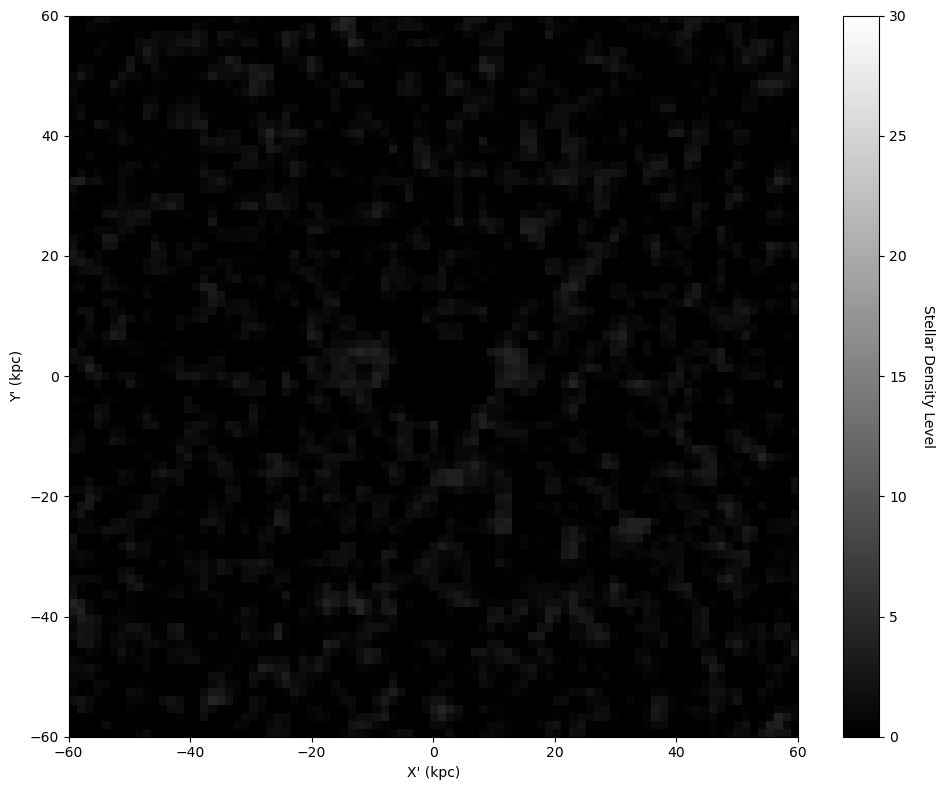

In [13]:
# apply the 2D exponential fit algorithm

if os.path.exists(centers_path):
    os.remove(centers_path)

for file in sorted(mf_catalogs_path.iterdir()):
    if file.is_file():

        print(f'File name: {file.name}')

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]
        
        hdul = fits.open(f'{mf_catalogs_path}/{file.name}')
        data=hdul[0].data

        # generate synthetic mock data with noise
        x_line = np.linspace(-60, 60, 89)
        y_line = np.linspace(-60, 60, 89)
        X, Y = np.meshgrid(x_line, y_line)
        
        # Flatten the arrays to 1-D for curve_fit
        x_flat = X.ravel()
        y_flat = Y.ravel()
        z_flat = data.ravel()
        
        # combine independent variables into an (2, N) shaped array
        independent_vars = np.vstack((x_flat, y_flat))
        
        # perform the optimization
        fitted_params, covariance = curve_fit(
            f=exponential_2d, 
            xdata=independent_vars, 
            ydata=z_flat, 
            p0=initial_guess
        )

        Z_fitted = exponential_2d((X, Y), *fitted_params)

        z_fit_max = np.max(Z_fitted)
        mask_thresh = mask_cutoff * z_fit_max # change thresh to what you want
        mask = Z_fitted < mask_thresh
        residual = data - Z_fitted
        masked_residual = residual.copy()
        masked_residual[~mask] = 0

        # Extract and view results
        A_fit, h_fit, q_fit, x_offset_fit, y_offset_fit, theta_fit, C_fit = fitted_params
        print("Fitted Parameters:")
        print(f"A  = {A_fit:.4f}")
        print(f"h = {h_fit:.4f}")
        print(f"q = {q_fit:.4f}")
        print(f"x_offset = {x_offset_fit:.4f}")
        print(f"y_offset = {y_offset_fit:.4f}")
        print(f"theta = {theta_fit:.4f}")
        print(f"C  = {C_fit:.4f}")

        with open(f'{centers_path}', 'a') as file:
            file.write('center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}' ':' f'{x_offset_fit:.4f}' ',' f'{y_offset_fit:.4f}' '\n')

        plot(data, f'original', d, a, save=True)
        plot(Z_fitted, f'model', d, a, save=True)
        plot(masked_residual, f'reduced', d, a, save=True, save_fits=True)